# Multi-task ablation across all sensor combinations

This notebook extends the OE-only multi-task notebook to **all seven sensor combinations**:

1. `OE`
2. `OPTI`
3. `XSENS`
4. `OE_OPTI`
5. `OE_XSENS`
6. `OPTI_XSENS`
7. `OE_OPTI_XSENS`

It runs the same tasks:

1. **interaction vs non_interaction** from the 5-second binary dataset
2. **conversation vs non_conversation** from the 10-second 3-class activity dataset
3. **conversation vs co_building**
4. **conversation vs co_merging**
5. **co_merging vs co_building**
6. **three-class activity recognition**: co_building vs co_merging vs conversation

For every task and sensor combination, it runs:

- **Classical no elapsed**
- **Classical with causal elapsed**
- **DL no elapsed**

Evaluation is **LOGO**: leave-one-group-out.

Important: the full DL sweep is large because it multiplies tasks × sensor combinations × sequence lengths × feature counts × model types. Start with the smoke-test setting first, then turn the full run on.

In [1]:
# ================================================================
# SETUP
# ================================================================

import os
import re
import gc
import json
import random
import warnings
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", None)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# ================================================================
# CONFIG
# ================================================================

DATA_ROOT = "/content/drive/MyDrive/thesis/data"

# 10-second activity recognition dataset.
ACTIVITY_DATA_PATH = f"{DATA_ROOT}/INTERACTION_ABLATIONS/activity3_advanced_merged_10s_features.csv"

# 5-second binary interaction dataset.
# Preferred path is the specialized OE merged dataset because it contains all sensors plus improved OE features.
INTERACTION_DATA_PATHS = [
    f"{DATA_ROOT}/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv",
    f"{DATA_ROOT}/INTERACTION_BINARY_5S_ADVANCED_FEATURES/binary_5s_all_sensor_advanced_features.csv",
]

OUT_DIR = f"{DATA_ROOT}/ALL_SENSOR_MULTI_TASK_ABLATIONS"
os.makedirs(OUT_DIR, exist_ok=True)

RUN_TASKS = [
    "interaction_vs_noninteraction",
    "conversation_vs_nonconversation",
    "conversation_vs_building",
    "conversation_vs_merging",
    "merging_vs_building",
    "three_class_activity",
]

SENSOR_COMBINATIONS = {
    "OE": ["OE"],
    "OPTI": ["OPTI"],
    "XSENS": ["XSENS"],
    "OE_OPTI": ["OE", "OPTI"],
    "OE_XSENS": ["OE", "XSENS"],
    "OPTI_XSENS": ["OPTI", "XSENS"],
    "OE_OPTI_XSENS": ["OE", "OPTI", "XSENS"],
}

RUN_CLASSICAL = True
RUN_DL = True

# Classical grid.
K_CLASSICAL = [40, 80, 120, 200, "all"]
TIME_CONDITIONS = ["no_elapsed", "with_elapsed"]

# DL grid.
K_DL = [80, 120, 200]
SEEDS = [42]
MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 64

# Full model list = ["lstm", "bilstm", "gru", "transformer"]
# For a faster but still meaningful run, use ["gru", "transformer"].
RUN_DL_MODEL_TYPES = ["lstm", "bilstm", "gru", "transformer"]

# Smoke test: set this to 4 first to make sure everything runs.
# Full run: set to None.
STOP_AFTER_N_DL_RUNS_PER_TASK_SENSOR = None

RANDOM_STATE = 42

In [ ]:
# ================================================================
# GENERAL HELPERS
# ================================================================

def safe_name(x):
    x = str(x)
    x = re.sub(r"[^A-Za-z0-9_]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


def unique_feats(feats):
    return list(dict.fromkeys(feats))


def find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None


def infer_window_seconds(df, start_col, end_col, default):
    if start_col in df.columns and end_col in df.columns:
        dur = pd.to_numeric(df[end_col], errors="coerce") - pd.to_numeric(df[start_col], errors="coerce")
        val = float(np.nanmedian(dur))
        if np.isfinite(val) and val > 0:
            return val
    return float(default)


def add_elapsed_min(df, group_col, start_col, end_col):
    df = df.copy()
    if "elapsed_min" in df.columns:
        df["elapsed_min"] = pd.to_numeric(df["elapsed_min"], errors="coerce")
        return df

    if start_col not in df.columns:
        raise ValueError(f"Cannot create elapsed_min because {start_col} is missing.")

    if end_col in df.columns:
        df["window_mid"] = (
            pd.to_numeric(df[start_col], errors="coerce") +
            pd.to_numeric(df[end_col], errors="coerce")
        ) / 2.0
    else:
        df["window_mid"] = pd.to_numeric(df[start_col], errors="coerce")

    df["elapsed_min"] = (df["window_mid"] - df.groupby(group_col)["window_mid"].transform("min")) / 60.0
    return df


BAD_TOKENS = [
    "label", "target", "class", "group", "window", "time", "elapsed",
    "pred", "prediction", "correct", "fold", "split", "index"
]


def looks_bad_feature_name(c):
    cl = str(c).lower()
    return any(tok in cl for tok in BAD_TOKENS)


def is_oe_feature(c):
    c = str(c)
    cl = c.lower()
    if looks_bad_feature_name(c):
        return False
    return (
        c.startswith("oe__")
        or c.startswith("oe_")
        or c.startswith("oebest__")
        or c.startswith("ear_")
        or c.startswith("mag__")
        or c.startswith("mag_")
    )


def is_opti_feature(c):
    c = str(c)
    cl = c.lower()
    if looks_bad_feature_name(c):
        return False

    # Current advanced merged datasets normally use opti2_ / opti2__ prefixes.
    if c.startswith("opti2_") or c.startswith("opti2__") or c.startswith("opti__") or c.startswith("opti_"):
        return True

    # Fallback for older unprefixed OptiTrack feature names.
    # Kept conservative to avoid catching OE/XSens features.
    fallback_tokens = [
        "dist_close", "dist_mid", "dist_far", "dist_disp",
        "centroid", "spread", "triangle", "perimeter", "compactness",
        "nearest", "farthest", "pairdist", "pair_dist",
        "approach", "separation", "proximity", "relative_pos",
    ]
    if any(tok in cl for tok in fallback_tokens):
        return True

    # Some old OptiTrack columns used simple speed names.
    if cl in {"speed_min", "speed_mid", "speed_max", "centroid_speed"}:
        return True

    return False


def is_xsens_feature(c):
    c = str(c)
    cl = c.lower()
    if looks_bad_feature_name(c):
        return False
    return (
        c.startswith("xsens2__")
        or c.startswith("xsens2_")
        or c.startswith("xsens__")
        or c.startswith("xsens_")
    )


def clean_feature_list(dataframe, feats, label_cols=None, include_elapsed=False):
    label_cols = set(label_cols or [])
    bad_cols = set(label_cols) | {
        "group", "window_start", "window_end", "window_mid", "video_time_s", "time_s",
        "label", "target", "class", "activity", "activity_class", "general_class",
        "binary_label", "recognition_label", "task_label", "pred", "prediction", "correct",
    }

    cleaned = []
    for f in unique_feats(feats):
        if f not in dataframe.columns:
            continue
        if f in bad_cols:
            continue

        fl = str(f).lower()
        if f == "elapsed_min":
            if include_elapsed:
                cleaned.append(f)
            continue

        if not include_elapsed and "elapsed" in fl:
            continue
        if any(tok in fl for tok in ["label", "target", "pred", "prediction", "correct"]):
            continue

        x = pd.to_numeric(dataframe[f], errors="coerce").values
        if np.isfinite(x).sum() < 20:
            continue
        if np.nanstd(x) < 1e-12:
            continue
        cleaned.append(f)

    return unique_feats(cleaned)


def make_classical_models(n_classes):
    return {
        "logreg_C1": LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear" if n_classes == 2 else "lbfgs",
            multi_class="auto",
            random_state=RANDOM_STATE,
        ),
        "linearSVC_C1": LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=10000,
            dual=False,
        ),
        "rbfSVC_C1_gscale": SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "rf_leaf2": RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "extraTrees_leaf1": ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }


def build_pipeline(model, k, n_features):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
    if k != "all":
        actual_k = min(int(k), n_features)
        steps.append(("select", SelectKBest(f_classif, k=actual_k)))
    steps.append(("model", clone(model)))
    return Pipeline(steps)


def metric_dict(y_true, y_pred, label_order, prefix=""):
    out = {
        prefix + "accuracy": accuracy_score(y_true, y_pred),
        prefix + "macro_f1": f1_score(y_true, y_pred, labels=label_order, average="macro", zero_division=0),
        prefix + "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, zero_division=0
    )

    for lab, p, r, f, s in zip(label_order, pr, rc, f1, sup):
        safe = safe_name(lab)
        out[prefix + f"precision_{safe}"] = p
        out[prefix + f"recall_{safe}"] = r
        out[prefix + f"f1_{safe}"] = f
        out[prefix + f"support_{safe}"] = int(s)

    return out

In [ ]:
# ================================================================
# LOAD DATASETS AND CREATE TASKS
# ================================================================

# ---------- Load activity 10s dataset ----------
if not os.path.exists(ACTIVITY_DATA_PATH):
    raise FileNotFoundError(
        f"Could not find activity dataset:\n{ACTIVITY_DATA_PATH}\n"
        "Run the advanced merged 10s feature-generation cell first."
    )

activity_df_raw = pd.read_csv(ACTIVITY_DATA_PATH)
activity_df_raw["recognition_label"] = activity_df_raw["recognition_label"].astype(str).str.strip()
activity_df_raw = add_elapsed_min(activity_df_raw, "group", "window_start", "window_end")
activity_window_s = infer_window_seconds(activity_df_raw, "window_start", "window_end", default=10.0)

print("Loaded activity dataset:", ACTIVITY_DATA_PATH)
print("Shape:", activity_df_raw.shape)
print("Estimated window seconds:", activity_window_s)
display(activity_df_raw["recognition_label"].value_counts())

# ---------- Load binary interaction 5s dataset ----------
interaction_path = find_first_existing(INTERACTION_DATA_PATHS)
if interaction_path is None:
    print("WARNING: interaction binary dataset not found. Interaction task will be skipped.")
    interaction_df_raw = None
    interaction_window_s = 5.0
else:
    interaction_df_raw = pd.read_csv(interaction_path)
    interaction_df_raw["binary_label"] = interaction_df_raw["binary_label"].astype(str).str.strip()
    interaction_df_raw = add_elapsed_min(interaction_df_raw, "group", "window_start", "window_end")
    interaction_window_s = infer_window_seconds(interaction_df_raw, "window_start", "window_end", default=5.0)

    print("\nLoaded interaction dataset:", interaction_path)
    print("Shape:", interaction_df_raw.shape)
    print("Estimated window seconds:", interaction_window_s)
    display(interaction_df_raw["binary_label"].value_counts())


# ---------- Feature extraction per dataset ----------
def get_modality_features(df, label_cols=None):
    label_cols = label_cols or []

    oe_raw = [c for c in df.columns if is_oe_feature(c)]
    opti_raw = [c for c in df.columns if is_opti_feature(c)]
    xsens_raw = [c for c in df.columns if is_xsens_feature(c)]

    # Make modality sets mutually exclusive if broad fallback captured something unexpectedly.
    oe = clean_feature_list(df, oe_raw, label_cols=label_cols, include_elapsed=False)
    opti = clean_feature_list(df, [c for c in opti_raw if c not in oe], label_cols=label_cols, include_elapsed=False)
    xsens = clean_feature_list(df, [c for c in xsens_raw if c not in oe and c not in opti], label_cols=label_cols, include_elapsed=False)

    return {"OE": oe, "OPTI": opti, "XSENS": xsens}


def make_combo_feature_sets(df, modality_features, label_cols=None):
    combo_sets = {}
    combo_sets_elapsed = {}

    for combo_name, modalities in SENSOR_COMBINATIONS.items():
        feats = []
        for m in modalities:
            feats.extend(modality_features.get(m, []))
        feats = clean_feature_list(df, feats, label_cols=label_cols, include_elapsed=False)
        feats_elapsed = clean_feature_list(
            df,
            feats + (["elapsed_min"] if "elapsed_min" in df.columns else []),
            label_cols=label_cols,
            include_elapsed=True,
        )
        combo_sets[combo_name] = feats
        combo_sets_elapsed[combo_name] = feats_elapsed

    return combo_sets, combo_sets_elapsed


# ---------- Task preparation ----------
def prepare_task(task_name):
    if task_name == "interaction_vs_noninteraction":
        if interaction_df_raw is None:
            return None

        df = interaction_df_raw.copy()
        label_col = "binary_label"
        labels = ["interaction", "non_interaction"]
        df = df[df[label_col].isin(labels)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = df[label_col]
        default_seq_lens = [6, 12, 18]   # 5s windows -> 30/60/90s
        window_s = interaction_window_s

    elif task_name == "conversation_vs_nonconversation":
        df = activity_df_raw.copy()
        label_col = "recognition_label"
        core = ["co_building", "co_merging", "conversation"]
        df = df[df[label_col].isin(core)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = np.where(df[label_col] == "conversation", "conversation", "non_conversation")
        labels = ["conversation", "non_conversation"]
        default_seq_lens = [3, 6, 9]
        window_s = activity_window_s

    elif task_name == "conversation_vs_building":
        df = activity_df_raw.copy()
        label_col = "recognition_label"
        labels = ["conversation", "co_building"]
        df = df[df[label_col].isin(labels)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = df[label_col]
        default_seq_lens = [3, 6, 9]
        window_s = activity_window_s

    elif task_name == "conversation_vs_merging":
        df = activity_df_raw.copy()
        label_col = "recognition_label"
        labels = ["conversation", "co_merging"]
        df = df[df[label_col].isin(labels)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = df[label_col]
        default_seq_lens = [3, 6, 9]
        window_s = activity_window_s

    elif task_name == "merging_vs_building":
        df = activity_df_raw.copy()
        label_col = "recognition_label"
        labels = ["co_merging", "co_building"]
        df = df[df[label_col].isin(labels)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = df[label_col]
        default_seq_lens = [3, 6, 9]
        window_s = activity_window_s

    elif task_name == "three_class_activity":
        df = activity_df_raw.copy()
        label_col = "recognition_label"
        labels = ["co_building", "co_merging", "conversation"]
        df = df[df[label_col].isin(labels)].copy().reset_index(drop=True)
        target_col = "task_label"
        df[target_col] = df[label_col]
        default_seq_lens = [3, 6, 9]
        window_s = activity_window_s

    else:
        raise ValueError(f"Unknown task: {task_name}")

    if len(df) == 0:
        print("Skipping empty task:", task_name)
        return None

    modality_features = get_modality_features(df, label_cols=[label_col, target_col])
    combo_sets, combo_sets_elapsed = make_combo_feature_sets(df, modality_features, label_cols=[label_col, target_col])

    spec = {
        "task_name": task_name,
        "df": df,
        "label_col": label_col,
        "target_col": target_col,
        "label_order": labels,
        "group_col": "group",
        "start_col": "window_start",
        "end_col": "window_end",
        "window_seconds": window_s,
        "seq_lens": default_seq_lens,
        "modality_features": modality_features,
        "combo_features": combo_sets,
        "combo_features_elapsed": combo_sets_elapsed,
        "out_dir": os.path.join(OUT_DIR, task_name),
    }
    os.makedirs(spec["out_dir"], exist_ok=True)
    return spec


task_specs = []
for task in RUN_TASKS:
    spec = prepare_task(task)
    if spec is not None:
        task_specs.append(spec)

print("\n" + "=" * 100)
print("PREPARED TASKS AND SENSOR COMBINATIONS")
print("=" * 100)

for spec in task_specs:
    print("\nTASK:", spec["task_name"])
    print("Rows:", len(spec["df"]))
    print("Classes:", spec["label_order"])
    print("Window seconds:", spec["window_seconds"])
    print("Seq lens:", spec["seq_lens"])
    print("Modality counts:", {k: len(v) for k, v in spec["modality_features"].items()})
    print("Combination counts, no elapsed:", {k: len(v) for k, v in spec["combo_features"].items()})
    print("Combination counts, with elapsed:", {k: len(v) for k, v in spec["combo_features_elapsed"].items()})
    display(spec["df"][spec["target_col"]].value_counts())
    display(pd.crosstab(spec["df"][spec["group_col"]], spec["df"][spec["target_col"]]))

    feature_count_rows = []
    for combo in SENSOR_COMBINATIONS:
        feature_count_rows.append({
            "task": spec["task_name"],
            "sensor_combo": combo,
            "n_no_elapsed": len(spec["combo_features"][combo]),
            "n_with_elapsed": len(spec["combo_features_elapsed"][combo]),
        })
    pd.DataFrame(feature_count_rows).to_csv(os.path.join(spec["out_dir"], f"{spec['task_name']}_feature_counts.csv"), index=False)

Loaded activity dataset: /content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/activity3_advanced_merged_10s_features.csv
Shape: (992, 1543)
Estimated window seconds: 10.0


,count
recognition_label,
co_building,548
conversation,311
co_merging,133



Loaded interaction dataset: /content/drive/MyDrive/thesis/data/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Shape: (4579, 1515)
Estimated window seconds: 5.0


,count
binary_label,
non_interaction,2304
interaction,2275



PREPARED TASKS AND SENSOR COMBINATIONS

TASK: interaction_vs_noninteraction
Rows: 4579
Classes: ['interaction', 'non_interaction']
Window seconds: 5.0
Seq lens: [6, 12, 18]
Modality counts: {'OE': 457, 'OPTI': 387, 'XSENS': 615}
Combination counts, no elapsed: {'OE': 457, 'OPTI': 387, 'XSENS': 615, 'OE_OPTI': 844, 'OE_XSENS': 1072, 'OPTI_XSENS': 1002, 'OE_OPTI_XSENS': 1459}
Combination counts, with elapsed: {'OE': 458, 'OPTI': 388, 'XSENS': 616, 'OE_OPTI': 845, 'OE_XSENS': 1073, 'OPTI_XSENS': 1003, 'OE_OPTI_XSENS': 1460}


...

,count
task_label,
co_building,548
co_merging,133


task_label,co_building,co_merging
group,,
1,9,43
2,80,0
3,39,8
5,89,28
6,43,10
7,113,24
8,54,4
9,107,11
10,14,5



TASK: three_class_activity
Rows: 992
Classes: ['co_building', 'co_merging', 'conversation']
Window seconds: 10.0
Seq lens: [3, 6, 9]
Modality counts: {'OE': 305, 'OPTI': 480, 'XSENS': 692}
Combination counts, no elapsed: {'OE': 305, 'OPTI': 480, 'XSENS': 692, 'OE_OPTI': 785, 'OE_XSENS': 997, 'OPTI_XSENS': 1172, 'OE_OPTI_XSENS': 1477}
Combination counts, with elapsed: {'OE': 306, 'OPTI': 481, 'XSENS': 693, 'OE_OPTI': 786, 'OE_XSENS': 998, 'OPTI_XSENS': 1173, 'OE_OPTI_XSENS': 1478}


,count
task_label,
co_building,548
conversation,311
co_merging,133


task_label,co_building,co_merging,conversation
group,,,
1,9,43,57
2,80,0,26
3,39,8,42
5,89,28,13
6,43,10,29
7,113,24,25
8,54,4,49
9,107,11,54
10,14,5,16


In [ ]:
# ================================================================
# CLASSICAL LOGO RUNNER
# ================================================================

def run_classical_for_task_and_sensor(spec, sensor_combo):
    task_name = spec["task_name"]
    df = spec["df"]
    y = df[spec["target_col"]].astype(str).values
    groups = df[spec["group_col"]].values
    label_order = spec["label_order"]
    n_classes = len(label_order)

    models = make_classical_models(n_classes)

    summary_rows = []
    pred_rows = []

    for time_condition in TIME_CONDITIONS:
        feats = spec["combo_features"][sensor_combo] if time_condition == "no_elapsed" else spec["combo_features_elapsed"][sensor_combo]

        if len(feats) == 0:
            print(f"Skipping classical | {task_name} | {sensor_combo} | {time_condition}: no features")
            continue

        for model_name, model in models.items():
            for k in K_CLASSICAL:
                if k != "all" and int(k) > len(feats):
                    continue

                print(
                    f"Running classical | {task_name} | {sensor_combo} | {time_condition} | "
                    f"{model_name} | k={k} | n_features={len(feats)}"
                )

                X = df[feats].apply(pd.to_numeric, errors="coerce").values
                pipe = build_pipeline(model, k, len(feats))
                logo = LeaveOneGroupOut()

                y_true_all = []
                y_pred_all = []
                group_all = []
                row_index_all = []

                for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
                    if len(np.unique(y[tr_idx])) < 2:
                        continue

                    pipe_fold = clone(pipe)
                    pipe_fold.fit(X[tr_idx], y[tr_idx])
                    pred = pipe_fold.predict(X[te_idx])

                    y_true_all.extend(y[te_idx])
                    y_pred_all.extend(pred)
                    group_all.extend(groups[te_idx])
                    row_index_all.extend(te_idx)

                if len(y_true_all) == 0:
                    continue

                metrics = metric_dict(np.array(y_true_all), np.array(y_pred_all), label_order)
                metrics.update({
                    "task": task_name,
                    "sensor_combo": sensor_combo,
                    "time_condition": time_condition,
                    "model": model_name,
                    "k": k,
                    "n_features": len(feats),
                    "n_rows_evaluated": len(y_true_all),
                })
                summary_rows.append(metrics)

                for idx, g, yt, yp in zip(row_index_all, group_all, y_true_all, y_pred_all):
                    pred_rows.append({
                        "task": task_name,
                        "sensor_combo": sensor_combo,
                        "time_condition": time_condition,
                        "model": model_name,
                        "k": k,
                        "row_index": int(idx),
                        "group": g,
                        "y_true": yt,
                        "y_pred": yp,
                        "correct": yt == yp,
                    })

    summary = pd.DataFrame(summary_rows)
    preds = pd.DataFrame(pred_rows)

    if len(summary) == 0:
        return summary, preds, pd.DataFrame()

    summary = summary.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

    best_per_condition = (
        summary
        .sort_values(["time_condition", "macro_f1", "accuracy"], ascending=[True, False, False])
        .groupby("time_condition", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    out_dir = os.path.join(spec["out_dir"], sensor_combo)
    os.makedirs(out_dir, exist_ok=True)

    summary.to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_summary.csv"), index=False)
    preds.to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_predictions.csv"), index=False)
    best_per_condition.to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_best_per_condition.csv"), index=False)

    print("\nTop classical results for", task_name, sensor_combo)
    display(summary.head(10).round(4))
    print("\nBest classical per time condition for", task_name, sensor_combo)
    display(best_per_condition.round(4))

    return summary, preds, best_per_condition


all_classical_summaries = []
all_classical_best = []

if RUN_CLASSICAL:
    for spec in task_specs:
        for sensor_combo in SENSOR_COMBINATIONS:
            print("\n" + "#" * 120)
            print("CLASSICAL TASK:", spec["task_name"], "| SENSOR:", sensor_combo)
            print("#" * 120)
            summary, preds, best = run_classical_for_task_and_sensor(spec, sensor_combo)
            if len(summary) > 0:
                all_classical_summaries.append(summary)
            if len(best) > 0:
                all_classical_best.append(best)

    if len(all_classical_summaries) > 0:
        combined_classical = pd.concat(all_classical_summaries, ignore_index=True)
        combined_classical.to_csv(os.path.join(OUT_DIR, "combined_classical_summary.csv"), index=False)

    if len(all_classical_best) > 0:
        combined_classical_best = pd.concat(all_classical_best, ignore_index=True)
        combined_classical_best.to_csv(os.path.join(OUT_DIR, "combined_classical_best_per_condition.csv"), index=False)

        print("\n" + "=" * 100)
        print("COMBINED CLASSICAL BESTS")
        print("=" * 100)
        display(combined_classical_best.round(4))


########################################################################################################################
CLASSICAL TASK: interaction_vs_noninteraction | SENSOR: OE
########################################################################################################################
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=40 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=80 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=120 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=200 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=all | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | linearSVC_C1 | k=40 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed 

KeyboardInterrupt: 

In [ ]:
# ================================================================
# CLASSICAL LOGO RUNNER - FAST / CONTROLLABLE VERSION
# ================================================================

from IPython.display import display
import os
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut

# ------------------------------------------------
# SPEED CONTROLS
# ------------------------------------------------

# Start with FAST mode.
# After you confirm everything works, you can set CLASSICAL_FAST_MODE = False.
CLASSICAL_FAST_MODE = True

# In fast mode, avoid slow RBF-SVC and tree models first.
FAST_CLASSICAL_MODELS = [
    "logreg_C1",
    "linearSVC_C1",
]

# Use fewer k values first.
# "all" can be slow for large sensor combinations.
FAST_K_CLASSICAL = [80, 200]

# For first test, you can restrict tasks/sensors.
# Set to None to run all.
CLASSICAL_TASKS_TO_RUN = None
# Example:
# CLASSICAL_TASKS_TO_RUN = ["interaction_vs_noninteraction"]

CLASSICAL_SENSOR_COMBOS_TO_RUN = None
# Example:
# CLASSICAL_SENSOR_COMBOS_TO_RUN = ["OE", "OPTI", "XSENS"]

# Save predictions for every model?
# False is much faster and lighter.
SAVE_CLASSICAL_PREDICTIONS = False

# Optional hard stop per task-sensor block.
# Use None for no limit.
MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR = None
# Example quick test:
# MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR = 6


def get_models_for_run(n_classes):
    models = make_classical_models(n_classes)

    if not CLASSICAL_FAST_MODE:
        return models

    filtered = {
        name: model
        for name, model in models.items()
        if name in FAST_CLASSICAL_MODELS
    }

    if len(filtered) == 0:
        print("Warning: FAST_CLASSICAL_MODELS did not match model names.")
        print("Available models:", list(models.keys()))
        print("Using all models instead.")
        return models

    return filtered


def get_k_values_for_run():
    if CLASSICAL_FAST_MODE:
        return FAST_K_CLASSICAL
    return K_CLASSICAL


def should_run_task(task_name):
    if CLASSICAL_TASKS_TO_RUN is None:
        return True
    return task_name in CLASSICAL_TASKS_TO_RUN


def should_run_sensor(sensor_combo):
    if CLASSICAL_SENSOR_COMBOS_TO_RUN is None:
        return True
    return sensor_combo in CLASSICAL_SENSOR_COMBOS_TO_RUN


def run_classical_for_task_and_sensor(spec, sensor_combo):
    task_name = spec["task_name"]
    df = spec["df"]

    y = df[spec["target_col"]].astype(str).values
    groups = df[spec["group_col"]].values
    label_order = spec["label_order"]
    n_classes = len(label_order)

    models = get_models_for_run(n_classes)
    k_values = get_k_values_for_run()

    summary_rows = []
    pred_rows = []

    config_count = 0

    # Pre-create LOGO once
    logo = LeaveOneGroupOut()

    for time_condition in TIME_CONDITIONS:

        if time_condition == "no_elapsed":
            feats = spec["combo_features"][sensor_combo]
        else:
            feats = spec["combo_features_elapsed"][sensor_combo]

        if len(feats) == 0:
            print(f"Skipping classical | {task_name} | {sensor_combo} | {time_condition}: no features")
            continue

        # Important speed improvement:
        # Create X once per time condition, not inside every model/k loop.
        X = df[feats].apply(pd.to_numeric, errors="coerce").values

        for model_name, model in models.items():
            for k in k_values:

                if k != "all" and int(k) > len(feats):
                    continue

                if MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR is not None:
                    if config_count >= MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR:
                        print(
                            f"Stopping early for {task_name} | {sensor_combo} "
                            f"after {config_count} configs."
                        )
                        break

                config_count += 1

                print(
                    f"Running classical | {task_name} | {sensor_combo} | {time_condition} | "
                    f"{model_name} | k={k} | n_features={len(feats)}"
                )

                pipe = build_pipeline(model, k, len(feats))

                y_true_all = []
                y_pred_all = []
                group_all = []
                row_index_all = []

                for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):

                    if len(np.unique(y[tr_idx])) < 2:
                        continue

                    pipe_fold = clone(pipe)
                    pipe_fold.fit(X[tr_idx], y[tr_idx])

                    pred = pipe_fold.predict(X[te_idx])

                    y_true_all.extend(y[te_idx])
                    y_pred_all.extend(pred)
                    group_all.extend(groups[te_idx])
                    row_index_all.extend(te_idx)

                if len(y_true_all) == 0:
                    continue

                y_true_all = np.array(y_true_all)
                y_pred_all = np.array(y_pred_all)

                metrics = metric_dict(y_true_all, y_pred_all, label_order)

                metrics.update({
                    "task": task_name,
                    "sensor_combo": sensor_combo,
                    "time_condition": time_condition,
                    "model": model_name,
                    "k": k,
                    "n_features": len(feats),
                    "n_rows_evaluated": len(y_true_all),
                })

                summary_rows.append(metrics)

                if SAVE_CLASSICAL_PREDICTIONS:
                    for idx, g, yt, yp in zip(row_index_all, group_all, y_true_all, y_pred_all):
                        pred_rows.append({
                            "task": task_name,
                            "sensor_combo": sensor_combo,
                            "time_condition": time_condition,
                            "model": model_name,
                            "k": k,
                            "row_index": int(idx),
                            "group": g,
                            "y_true": yt,
                            "y_pred": yp,
                            "correct": yt == yp,
                        })

            if MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR is not None:
                if config_count >= MAX_CLASSICAL_CONFIGS_PER_TASK_SENSOR:
                    break

    summary = pd.DataFrame(summary_rows)
    preds = pd.DataFrame(pred_rows)

    if len(summary) == 0:
        return summary, preds, pd.DataFrame()

    summary = (
        summary
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )

    best_per_condition = (
        summary
        .sort_values(
            ["time_condition", "macro_f1", "accuracy"],
            ascending=[True, False, False]
        )
        .groupby("time_condition", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    out_dir = os.path.join(spec["out_dir"], sensor_combo)
    os.makedirs(out_dir, exist_ok=True)

    summary.to_csv(
        os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_summary.csv"),
        index=False
    )

    if SAVE_CLASSICAL_PREDICTIONS and len(preds) > 0:
        preds.to_csv(
            os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_predictions.csv"),
            index=False
        )

    best_per_condition.to_csv(
        os.path.join(out_dir, f"{task_name}_{sensor_combo}_classical_best_per_condition.csv"),
        index=False
    )

    print("\nTop classical results for", task_name, sensor_combo)
    display(summary.head(10).round(4))

    print("\nBest classical per time condition for", task_name, sensor_combo)
    display(best_per_condition.round(4))

    return summary, preds, best_per_condition


# ================================================================
# RUN CLASSICAL
# ================================================================

all_classical_summaries = []
all_classical_best = []

if RUN_CLASSICAL:

    print("=" * 100)
    print("CLASSICAL RUN SETTINGS")
    print("=" * 100)
    print("CLASSICAL_FAST_MODE:", CLASSICAL_FAST_MODE)
    print("FAST_CLASSICAL_MODELS:", FAST_CLASSICAL_MODELS if CLASSICAL_FAST_MODE else "all")
    print("K values:", get_k_values_for_run())
    print("SAVE_CLASSICAL_PREDICTIONS:", SAVE_CLASSICAL_PREDICTIONS)
    print("CLASSICAL_TASKS_TO_RUN:", CLASSICAL_TASKS_TO_RUN)
    print("CLASSICAL_SENSOR_COMBOS_TO_RUN:", CLASSICAL_SENSOR_COMBOS_TO_RUN)
    print("=" * 100)

    for spec in task_specs:

        task_name = spec["task_name"]

        if not should_run_task(task_name):
            print("Skipping task:", task_name)
            continue

        for sensor_combo in SENSOR_COMBINATIONS:

            if not should_run_sensor(sensor_combo):
                print("Skipping sensor combo:", sensor_combo)
                continue

            print("\n" + "#" * 120)
            print("CLASSICAL TASK:", task_name, "| SENSOR:", sensor_combo)
            print("#" * 120)

            summary, preds, best = run_classical_for_task_and_sensor(spec, sensor_combo)

            if len(summary) > 0:
                all_classical_summaries.append(summary)

            if len(best) > 0:
                all_classical_best.append(best)

    if len(all_classical_summaries) > 0:
        combined_classical = pd.concat(all_classical_summaries, ignore_index=True)

        combined_classical.to_csv(
            os.path.join(OUT_DIR, "combined_classical_summary.csv"),
            index=False
        )

    if len(all_classical_best) > 0:
        combined_classical_best = pd.concat(all_classical_best, ignore_index=True)

        combined_classical_best.to_csv(
            os.path.join(OUT_DIR, "combined_classical_best_per_condition.csv"),
            index=False
        )

        print("\n" + "=" * 100)
        print("COMBINED CLASSICAL BESTS")
        print("=" * 100)
        display(combined_classical_best.round(4))

CLASSICAL RUN SETTINGS
CLASSICAL_FAST_MODE: True
FAST_CLASSICAL_MODELS: ['logreg_C1', 'linearSVC_C1']
K values: [80, 200]
SAVE_CLASSICAL_PREDICTIONS: False
CLASSICAL_TASKS_TO_RUN: None
CLASSICAL_SENSOR_COMBOS_TO_RUN: None

########################################################################################################################
CLASSICAL TASK: interaction_vs_noninteraction | SENSOR: OE
########################################################################################################################
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=80 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | logreg_C1 | k=200 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | linearSVC_C1 | k=80 | n_features=457
Running classical | interaction_vs_noninteraction | OE | no_elapsed | linearSVC_C1 | k=200 | n_features=457
Running classical | interaction_vs_noninteraction | 

,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,time_condition,model,k,n_features,n_rows_evaluated
0,0.6988,0.6988,0.6989,0.6910,0.7125,0.7016,2275,0.7071,0.6853,0.6961,2304,interaction_vs_noninteraction,OE,with_elapsed,logreg_C1,200,458,4579
1,0.6960,0.6960,0.6961,0.6881,0.7099,0.6988,2275,0.7043,0.6823,0.6931,2304,interaction_vs_noninteraction,OE,with_elapsed,linearSVC_C1,200,458,4579
2,0.6890,0.6890,0.6891,0.6833,0.6971,0.6902,2275,0.6949,0.6810,0.6879,2304,interaction_vs_noninteraction,OE,with_elapsed,logreg_C1,80,458,4579
3,0.6833,0.6833,0.6834,0.6767,0.6945,0.6855,2275,0.6903,0.6723,0.6812,2304,interaction_vs_noninteraction,OE,with_elapsed,linearSVC_C1,80,458,4579
4,0.6355,0.6345,0.6359,0.6193,0.6914,0.6534,2275,0.6557,0.5803,0.6157,2304,interaction_vs_noninteraction,OE,no_elapsed,logreg_C1,200,457,4579
5,0.6351,0.6341,0.6354,0.6190,0.6905,0.6528,2275,0.6551,0.5803,0.6154,2304,interaction_vs_noninteraction,OE,no_elapsed,linearSVC_C1,200,457,4579
6,0.5779,0.5769,0.5782,0.5680,0.6281,0.5965,2275,0.5899,0.5282,0.5574,2304,interaction_vs_noninteraction,OE,no_elapsed,logreg_C1,80,457,4579
7,0.5691,0.5671,0.5696,0.5577,0.6418,0.5968,2275,0.5844,0.4974,0.5374,2304,interaction_vs_noninteraction,OE,no_elapsed,linearSVC_C1,80,457,4579



Best classical per time condition for interaction_vs_noninteraction OE


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,time_condition,model,k,n_features,n_rows_evaluated
0,0.6355,0.6345,0.6359,0.6193,0.6914,0.6534,2275,0.6557,0.5803,0.6157,2304,interaction_vs_noninteraction,OE,no_elapsed,logreg_C1,200,457,4579
1,0.6988,0.6988,0.6989,0.6910,0.7125,0.7016,2275,0.7071,0.6853,0.6961,2304,interaction_vs_noninteraction,OE,with_elapsed,logreg_C1,200,458,4579



########################################################################################################################
CLASSICAL TASK: interaction_vs_noninteraction | SENSOR: OPTI
########################################################################################################################
Running classical | interaction_vs_noninteraction | OPTI | no_elapsed | logreg_C1 | k=80 | n_features=387
Running classical | interaction_vs_noninteraction | OPTI | no_elapsed | logreg_C1 | k=200 | n_features=387
Running classical | interaction_vs_noninteraction | OPTI | no_elapsed | linearSVC_C1 | k=80 | n_features=387
Running classical | interaction_vs_noninteraction | OPTI | no_elapsed | linearSVC_C1 | k=200 | n_features=387
Running classical | interaction_vs_noninteraction | OPTI | with_elapsed | logreg_C1 | k=80 | n_features=388
Running classical | interaction_vs_noninteraction | OPTI | with_elapsed | logreg_C1 | k=200 | n_features=388
Running classical | interaction_vs_noninteracti

...

,accuracy,macro_f1,balanced_accuracy,precision_co_building,recall_co_building,f1_co_building,support_co_building,precision_co_merging,recall_co_merging,f1_co_merging,support_co_merging,precision_conversation,recall_conversation,f1_conversation,support_conversation,task,sensor_combo,time_condition,model,k,n_features,n_rows_evaluated
0,0.6946,0.6530,0.6874,0.8210,0.6697,0.7377,548,0.3705,0.6241,0.4650,133,0.7445,0.7685,0.7563,311,three_class_activity,OE_OPTI_XSENS,no_elapsed,logreg_C1,80,1477,992
1,0.7258,0.6373,0.6328,0.7729,0.8011,0.7867,548,0.4054,0.3383,0.3689,133,0.7540,0.7588,0.7564,311,three_class_activity,OE_OPTI_XSENS,no_elapsed,linearSVC_C1,80,1477,992
2,0.7218,0.6234,0.6254,0.7837,0.7737,0.7787,548,0.3276,0.2857,0.3052,133,0.7582,0.8167,0.7864,311,three_class_activity,OE_OPTI_XSENS,with_elapsed,linearSVC_C1,80,1478,992
3,0.6381,0.6001,0.6380,0.7792,0.5602,0.6518,548,0.2689,0.5338,0.3577,133,0.7635,0.8199,0.7907,311,three_class_activity,OE_OPTI_XSENS,with_elapsed,logreg_C1,80,1478,992
4,0.5605,0.5378,0.5981,0.7859,0.4489,0.5714,548,0.2508,0.6090,0.3553,133,0.6433,0.7363,0.6867,311,three_class_activity,OE_OPTI_XSENS,with_elapsed,logreg_C1,200,1478,992
5,0.5605,0.5366,0.5940,0.7890,0.4708,0.5897,548,0.2587,0.6165,0.3644,133,0.6207,0.6945,0.6555,311,three_class_activity,OE_OPTI_XSENS,no_elapsed,linearSVC_C1,200,1477,992
6,0.5544,0.5335,0.5974,0.7941,0.4434,0.5691,548,0.2553,0.6316,0.3636,133,0.6246,0.7170,0.6677,311,three_class_activity,OE_OPTI_XSENS,no_elapsed,logreg_C1,200,1477,992
7,0.5413,0.5130,0.5648,0.7690,0.4434,0.5625,548,0.2391,0.5338,0.3302,133,0.5884,0.7170,0.6464,311,three_class_activity,OE_OPTI_XSENS,with_elapsed,linearSVC_C1,200,1478,992



Best classical per time condition for three_class_activity OE_OPTI_XSENS


,accuracy,macro_f1,balanced_accuracy,precision_co_building,recall_co_building,f1_co_building,support_co_building,precision_co_merging,recall_co_merging,f1_co_merging,support_co_merging,precision_conversation,recall_conversation,f1_conversation,support_conversation,task,sensor_combo,time_condition,model,k,n_features,n_rows_evaluated
0,0.6946,0.6530,0.6874,0.8210,0.6697,0.7377,548,0.3705,0.6241,0.4650,133,0.7445,0.7685,0.7563,311,three_class_activity,OE_OPTI_XSENS,no_elapsed,logreg_C1,80,1477,992
1,0.7218,0.6234,0.6254,0.7837,0.7737,0.7787,548,0.3276,0.2857,0.3052,133,0.7582,0.8167,0.7864,311,three_class_activity,OE_OPTI_XSENS,with_elapsed,linearSVC_C1,80,1478,992



COMBINED CLASSICAL BESTS


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,time_condition,model,k,n_features,n_rows_evaluated,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,precision_co_building,recall_co_building,f1_co_building,support_co_building,precision_co_merging,recall_co_merging,f1_co_merging,support_co_merging
0,0.6355,0.6345,0.6359,0.6193,0.6914,0.6534,2275.0,0.6557,0.5803,0.6157,2304.0,interaction_vs_noninteraction,OE,no_elapsed,logreg_C1,200,457,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.6988,0.6988,0.6989,0.6910,0.7125,0.7016,2275.0,0.7071,0.6853,0.6961,2304.0,interaction_vs_noninteraction,OE,with_elapsed,logreg_C1,200,458,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.7290,0.7290,0.7290,0.7268,0.7284,0.7276,2275.0,0.7312,0.7296,0.7304,2304.0,interaction_vs_noninteraction,OPTI,no_elapsed,linearSVC_C1,200,387,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.7502,0.7500,0.7500,0.7600,0.7266,0.7429,2275.0,0.7413,0.7734,0.7570,2304.0,interaction_vs_noninteraction,OPTI,with_elapsed,linearSVC_C1,80,388,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5165,0.5164,0.5166,0.5128,0.5354,0.5239,2275.0,0.5204,0.4978,0.5089,2304.0,interaction_vs_noninteraction,XSENS,no_elapsed,logreg_C1,80,615,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.6674,0.6672,0.6673,0.6706,0.6497,0.6600,2275.0,0.6644,0.6849,0.6745,2304.0,interaction_vs_noninteraction,XSENS,with_elapsed,logreg_C1,80,616,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.7248,0.7248,0.7249,0.7155,0.7407,0.7279,2275.0,0.7347,0.7092,0.7217,2304.0,interaction_vs_noninteraction,OE_OPTI,no_elapsed,linearSVC_C1,80,844,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.7403,0.7402,0.7402,0.7464,0.7231,0.7345,2275.0,0.7347,0.7574,0.7459,2304.0,interaction_vs_noninteraction,OE_OPTI,with_elapsed,linearSVC_C1,80,845,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.5534,0.5514,0.5538,0.5441,0.6237,0.5812,2275.0,0.5657,0.4839,0.5216,2304.0,interaction_vs_noninteraction,OE_XSENS,no_elapsed,logreg_C1,200,1072,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.6624,0.6597,0.6630,0.6345,0.7560,0.6899,2275.0,0.7029,0.5699,0.6294,2304.0,interaction_vs_noninteraction,OE_XSENS,with_elapsed,logreg_C1,80,1073,4579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ================================================================
# DL MODEL HELPERS
# ================================================================

class RNNClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, rnn_type="lstm", hidden_dim=64, num_layers=1, dropout=0.25, bidirectional=False):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, n_classes, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.25):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model=d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        out = self.encoder(x)
        last = out[:, -1, :]
        return self.head(last)


ALL_MODEL_CONFIGS = [
    {"model_type": "lstm", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "bilstm", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "gru", "hidden_dim": 64, "num_layers": 1, "dropout": 0.25, "lr": 1e-3, "weight_decay": 1e-4},
    {"model_type": "transformer", "d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.25, "lr": 5e-4, "weight_decay": 1e-4},
]

MODEL_CONFIGS = [m for m in ALL_MODEL_CONFIGS if m["model_type"] in RUN_DL_MODEL_TYPES]
print("DL model types:", [m["model_type"] for m in MODEL_CONFIGS])


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_model(model_cfg, input_dim, n_classes):
    mt = model_cfg["model_type"]
    if mt == "lstm":
        return RNNClassifier(input_dim, n_classes, rnn_type="lstm", hidden_dim=model_cfg["hidden_dim"], num_layers=model_cfg["num_layers"], dropout=model_cfg["dropout"], bidirectional=False)
    if mt == "bilstm":
        return RNNClassifier(input_dim, n_classes, rnn_type="lstm", hidden_dim=model_cfg["hidden_dim"], num_layers=model_cfg["num_layers"], dropout=model_cfg["dropout"], bidirectional=True)
    if mt == "gru":
        return RNNClassifier(input_dim, n_classes, rnn_type="gru", hidden_dim=model_cfg["hidden_dim"], num_layers=model_cfg["num_layers"], dropout=model_cfg["dropout"], bidirectional=False)
    if mt == "transformer":
        return TransformerClassifier(input_dim, n_classes, d_model=model_cfg["d_model"], nhead=model_cfg["nhead"], num_layers=model_cfg["num_layers"], dim_feedforward=model_cfg["dim_feedforward"], dropout=model_cfg["dropout"])
    raise ValueError(mt)


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def make_sequences(X, y, groups, starts, seq_len):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)
    groups = np.asarray(groups)
    starts = np.asarray(starts, dtype=float)

    Xs, ys, gs, sts = [], [], [], []

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        idx = idx[np.argsort(starts[idx])]
        if len(idx) < seq_len:
            continue
        for end_pos in range(seq_len - 1, len(idx)):
            win_idx = idx[end_pos - seq_len + 1:end_pos + 1]
            Xs.append(X[win_idx])
            ys.append(y[idx[end_pos]])
            gs.append(g)
            sts.append(starts[idx[end_pos]])

    if len(Xs) == 0:
        return np.empty((0, seq_len, X.shape[1]), dtype=np.float32), np.array([]), np.array([]), np.array([])

    return np.stack(Xs).astype(np.float32), np.array(ys), np.array(gs), np.array(sts)


def torch_predict(model, X, batch_size=512):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)


def choose_validation_group(train_groups, y_all, groups_all):
    candidates = []
    for g in sorted(np.unique(train_groups)):
        mask = groups_all == g
        n_classes = len(np.unique(y_all[mask]))
        n_rows = int(mask.sum())
        candidates.append((n_classes >= 2, n_rows, g))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][2]

DL model types: ['lstm', 'bilstm', 'gru', 'transformer']


In [ ]:
# ================================================================
# FAST DL TRAINING / EVALUATION
# Run this instead of the full DL grid.
# ================================================================

import os
import gc
import time
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score

# ------------------------------------------------
# FAST DL SETTINGS
# ------------------------------------------------

RUN_DL = True

# Keep all tasks and all sensor combinations.
# This gives one fast but meaningful DL result per task/sensor.
FAST_DL_TASKS_TO_RUN = None
FAST_DL_SENSOR_COMBOS_TO_RUN = None

# Use only one strong model first.
# GRU is usually faster than Transformer and often stable.
FAST_DL_MODEL_TYPES = ["gru"]

# Use only one k value.
# The code automatically uses min(k, number of available features).
FAST_DL_K = 120

# Use only one sequence length per task.
# "last" means longest context:
# interaction 5s: seq_len 18 = 90s
# activity 10s: seq_len 9 = 90s
FAST_DL_SEQ_CHOICE = "last"

# Much faster training.
FAST_MAX_EPOCHS = 25
FAST_PATIENCE = 4
FAST_BATCH_SIZE = 256
FAST_PRED_BATCH_SIZE = 1024

# Full LOGO is still honest.
# Set to 3 only for a quick smoke test, not final thesis result.
MAX_LOGO_FOLDS = None

# Save row-level predictions?
# False is much faster and lighter.
SAVE_FAST_DL_PREDICTIONS = False

FAST_DL_OUT_DIR = os.path.join(OUT_DIR, "FAST_DL_NO_ELAPSED")
os.makedirs(FAST_DL_OUT_DIR, exist_ok=True)

print("FAST_DL_OUT_DIR:", FAST_DL_OUT_DIR)


def should_run_fast_dl_task(task_name):
    if FAST_DL_TASKS_TO_RUN is None:
        return True
    return task_name in FAST_DL_TASKS_TO_RUN


def should_run_fast_dl_sensor(sensor_combo):
    if FAST_DL_SENSOR_COMBOS_TO_RUN is None:
        return True
    return sensor_combo in FAST_DL_SENSOR_COMBOS_TO_RUN


def choose_fast_seq_len(spec):
    seq_lens = list(spec["seq_lens"])

    if FAST_DL_SEQ_CHOICE == "last":
        return seq_lens[-1]
    if FAST_DL_SEQ_CHOICE == "first":
        return seq_lens[0]
    if FAST_DL_SEQ_CHOICE == "middle":
        return seq_lens[len(seq_lens) // 2]

    return int(FAST_DL_SEQ_CHOICE)


def get_fast_model_configs():
    return [
        cfg for cfg in MODEL_CONFIGS
        if cfg["model_type"] in FAST_DL_MODEL_TYPES
    ]


def torch_predict_fast(model, X, batch_size=FAST_PRED_BATCH_SIZE):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            preds.extend(logits.argmax(1).cpu().numpy())

    return np.array(preds)


def train_one_fast_dl_run(spec, sensor_combo, seq_len, k_features, model_cfg, seed):
    set_seed(seed)

    task_name = spec["task_name"]
    df = spec["df"]

    feature_list = spec["combo_features"][sensor_combo].copy()
    label_order = spec["label_order"]
    n_classes = len(label_order)

    if len(feature_list) == 0:
        return None, None, None

    label_to_id = {lab: i for i, lab in enumerate(label_order)}
    id_to_label = {i: lab for lab, i in label_to_id.items()}

    y_label = df[spec["target_col"]].astype(str).values
    y_all = np.array([label_to_id[v] for v in y_label], dtype=int)

    groups_all = df[spec["group_col"]].values
    starts_all = pd.to_numeric(df[spec["start_col"]], errors="coerce").values

    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    fold_rows = []
    pred_rows = []

    fold_counter = 0

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):

        fold_counter += 1
        if MAX_LOGO_FOLDS is not None and fold_counter > MAX_LOGO_FOLDS:
            break

        if len(np.unique(y_all[trval_idx])) < 2:
            continue

        test_group = groups_all[te_idx][0]

        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups, y_all, groups_all)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        if len(np.unique(y_all[tr_idx])) < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(X_raw[tr_idx])
        Xval = imputer.transform(X_raw[val_idx])
        Xte = imputer.transform(X_raw[te_idx])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(int(k_features), Xtr.shape[1])

        selector = SelectKBest(f_classif, k=actual_k)
        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        Xtr_seq, ytr_seq, _, _ = make_sequences(
            Xtr, y_all[tr_idx], groups_all[tr_idx], starts_all[tr_idx], seq_len
        )
        Xval_seq, yval_seq, _, _ = make_sequences(
            Xval, y_all[val_idx], groups_all[val_idx], starts_all[val_idx], seq_len
        )
        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte, y_all[te_idx], groups_all[te_idx], starts_all[te_idx], seq_len
        )

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            continue

        model = build_model(model_cfg, input_dim=actual_k, n_classes=n_classes).to(DEVICE)

        opt = torch.optim.AdamW(
            model.parameters(),
            lr=model_cfg["lr"],
            weight_decay=model_cfg["weight_decay"]
        )

        loss_fn = nn.CrossEntropyLoss()

        train_loader = make_loader(
            Xtr_seq,
            ytr_seq,
            batch_size=FAST_BATCH_SIZE,
            shuffle=True
        )

        best_state = None
        best_val_macro = -1
        patience_left = FAST_PATIENCE
        best_epoch = 0

        for epoch in range(1, FAST_MAX_EPOCHS + 1):
            model.train()

            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            val_pred = torch_predict_fast(model, Xval_seq)
            val_macro = f1_score(yval_seq, val_pred, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_left = FAST_PATIENCE
                best_epoch = epoch
            else:
                patience_left -= 1

            if patience_left <= 0:
                break

        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(DEVICE)

        test_pred = torch_predict_fast(model, Xte_seq)

        y_true_all.extend(yte_seq.tolist())
        y_pred_all.extend(test_pred.tolist())

        fold_metrics_ids = metric_dict(yte_seq, test_pred, list(range(n_classes)))

        fold_rows.append({
            "task": task_name,
            "sensor_combo": sensor_combo,
            "fold": fold,
            "test_group": test_group,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * spec["window_seconds"],
            "k_features": actual_k,
            "n_features_before_select": len(feature_list),
            "n_sequences": len(Xte_seq),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro,
            "accuracy": fold_metrics_ids["accuracy"],
            "macro_f1": fold_metrics_ids["macro_f1"],
            "balanced_accuracy": fold_metrics_ids["balanced_accuracy"],
        })

        if SAVE_FAST_DL_PREDICTIONS:
            for yt, yp, g, st in zip(yte_seq, test_pred, gte_seq, ste_seq):
                pred_rows.append({
                    "task": task_name,
                    "sensor_combo": sensor_combo,
                    "model_type": model_cfg["model_type"],
                    "seed": seed,
                    "seq_len": seq_len,
                    "context_seconds": seq_len * spec["window_seconds"],
                    "k_features": actual_k,
                    "group": g,
                    "window_start": st,
                    "y_true": id_to_label[int(yt)],
                    "y_pred": id_to_label[int(yp)],
                    "correct": int(yt) == int(yp),
                })

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(y_true_all) == 0:
        return None, None, None

    y_true_lab = np.array([id_to_label[int(v)] for v in y_true_all])
    y_pred_lab = np.array([id_to_label[int(v)] for v in y_pred_all])

    summary = metric_dict(y_true_lab, y_pred_lab, label_order)

    summary.update({
        "task": task_name,
        "sensor_combo": sensor_combo,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * spec["window_seconds"],
        "k_features": int(k_features),
        "n_features_before_select": len(feature_list),
        "n_sequences_evaluated": len(y_true_lab),
        "time_condition": "no_elapsed",
        "feature_set": sensor_combo,
        "fast_dl": True,
        "max_epochs": FAST_MAX_EPOCHS,
        "patience": FAST_PATIENCE,
        "max_logo_folds": MAX_LOGO_FOLDS,
    })

    return summary, pd.DataFrame(fold_rows), pd.DataFrame(pred_rows)


# ================================================================
# RUN FAST DL
# ================================================================

fast_model_configs = get_fast_model_configs()

planned = []

for spec in task_specs:
    if not should_run_fast_dl_task(spec["task_name"]):
        continue

    seq_len = choose_fast_seq_len(spec)

    for sensor_combo in SENSOR_COMBINATIONS:
        if not should_run_fast_dl_sensor(sensor_combo):
            continue

        if sensor_combo not in spec["combo_features"]:
            continue

        if len(spec["combo_features"][sensor_combo]) == 0:
            continue

        for seed in SEEDS:
            for model_cfg in fast_model_configs:
                planned.append({
                    "task": spec["task_name"],
                    "sensor_combo": sensor_combo,
                    "seq_len": seq_len,
                    "k": min(FAST_DL_K, len(spec["combo_features"][sensor_combo])),
                    "model": model_cfg["model_type"],
                    "seed": seed,
                    "n_features_before_select": len(spec["combo_features"][sensor_combo]),
                })

planned_df = pd.DataFrame(planned)

print("=" * 100)
print("FAST DL PLAN")
print("=" * 100)
print("Number of displayed DL configs:", len(planned_df))

if MAX_LOGO_FOLDS is None:
    print("LOGO folds: full leave-one-group-out")
else:
    print("LOGO folds limited to:", MAX_LOGO_FOLDS)

display(planned_df)

planned_df.to_csv(os.path.join(FAST_DL_OUT_DIR, "fast_dl_plan.csv"), index=False)

all_fast_summaries = []
all_fast_folds = []
all_fast_preds = []

t0 = time.time()

for i, row in planned_df.iterrows():
    spec = next(s for s in task_specs if s["task_name"] == row["task"])
    model_cfg = next(c for c in fast_model_configs if c["model_type"] == row["model"])

    print("\n" + "#" * 120)
    print(
        f"FAST DL RUN {i + 1}/{len(planned_df)} | "
        f"{row['task']} | {row['sensor_combo']} | "
        f"{row['model']} | seq_len={row['seq_len']} | k={row['k']} | seed={row['seed']}"
    )
    print("#" * 120)

    run_t0 = time.time()

    summary, fold_df, pred_df = train_one_fast_dl_run(
        spec=spec,
        sensor_combo=row["sensor_combo"],
        seq_len=int(row["seq_len"]),
        k_features=int(row["k"]),
        model_cfg=model_cfg,
        seed=int(row["seed"]),
    )

    run_minutes = (time.time() - run_t0) / 60

    if summary is None:
        print("Skipped or failed: no valid sequences.")
        continue

    summary["runtime_minutes"] = run_minutes

    all_fast_summaries.append(summary)

    if fold_df is not None and len(fold_df) > 0:
        fold_df["runtime_minutes_parent_run"] = run_minutes
        all_fast_folds.append(fold_df)

    if pred_df is not None and len(pred_df) > 0:
        all_fast_preds.append(pred_df)

    current = (
        pd.DataFrame(all_fast_summaries)
        .sort_values(["task", "sensor_combo", "macro_f1", "accuracy"],
                     ascending=[True, True, False, False])
        .reset_index(drop=True)
    )

    display(
        current
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .head(15)
        .round(4)
    )

    current.to_csv(
        os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_summary.csv"),
        index=False
    )

    if len(all_fast_folds) > 0:
        pd.concat(all_fast_folds, ignore_index=True).to_csv(
            os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_fold_metrics.csv"),
            index=False
        )

    if SAVE_FAST_DL_PREDICTIONS and len(all_fast_preds) > 0:
        pd.concat(all_fast_preds, ignore_index=True).to_csv(
            os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_predictions.csv"),
            index=False
        )

    done = len(all_fast_summaries)
    elapsed_min = (time.time() - t0) / 60
    avg_min = elapsed_min / max(done, 1)
    remaining = len(planned_df) - (i + 1)

    print(f"Run took: {run_minutes:.1f} min")
    print(f"Elapsed: {elapsed_min:.1f} min")
    print(f"Average per completed run: {avg_min:.1f} min")
    print(f"Estimated remaining: {remaining * avg_min:.1f} min")

# ================================================================
# SAVE BEST PER TASK/SENSOR
# ================================================================

if len(all_fast_summaries) > 0:
    combined_fast_dl = pd.DataFrame(all_fast_summaries)

    combined_fast_dl.to_csv(
        os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_summary.csv"),
        index=False
    )

    combined_fast_dl_best = (
        combined_fast_dl
        .sort_values(
            ["task", "sensor_combo", "macro_f1", "accuracy"],
            ascending=[True, True, False, False]
        )
        .groupby(["task", "sensor_combo"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_path = os.path.join(
        FAST_DL_OUT_DIR,
        "combined_fast_dl_no_elapsed_best_per_task_sensor.csv"
    )

    combined_fast_dl_best.to_csv(best_path, index=False)

    print("\n" + "=" * 100)
    print("FAST DL BESTS")
    print("=" * 100)
    display(combined_fast_dl_best.round(4))

    print("\nSaved summary folder:")
    print(FAST_DL_OUT_DIR)

else:
    print("No FAST DL summaries were created.")

FAST_DL_OUT_DIR: /content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_NO_ELAPSED
FAST DL PLAN
Number of displayed DL configs: 42
LOGO folds: full leave-one-group-out


,task,sensor_combo,seq_len,k,model,seed,n_features_before_select
0,interaction_vs_noninteraction,OE,18,120,gru,42,457
1,interaction_vs_noninteraction,OPTI,18,120,gru,42,387
2,interaction_vs_noninteraction,XSENS,18,120,gru,42,615
3,interaction_vs_noninteraction,OE_OPTI,18,120,gru,42,844
4,interaction_vs_noninteraction,OE_XSENS,18,120,gru,42,1072
5,interaction_vs_noninteraction,OPTI_XSENS,18,120,gru,42,1002
6,interaction_vs_noninteraction,OE_OPTI_XSENS,18,120,gru,42,1459
7,conversation_vs_nonconversation,OE,9,120,gru,42,305
8,conversation_vs_nonconversation,OPTI,9,120,gru,42,480
9,conversation_vs_nonconversation,XSENS,9,120,gru,42,692



########################################################################################################################
FAST DL RUN 1/42 | interaction_vs_noninteraction | OE | gru | seq_len=18 | k=120 | seed=42
########################################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,model_type,seed,seq_len,context_seconds,k_features,n_features_before_select,n_sequences_evaluated,time_condition,feature_set,fast_dl,max_epochs,patience,max_logo_folds,runtime_minutes
0,0.5366,0.5351,0.5364,0.5341,0.5926,0.5618,2219,0.5397,0.4803,0.5083,2207,interaction_vs_noninteraction,OE,gru,42,18,90.0,120,457,4426,no_elapsed,OE,True,25,4,None,0.9825


Run took: 1.0 min
Elapsed: 1.0 min
Average per completed run: 1.0 min
Estimated remaining: 40.3 min

########################################################################################################################
FAST DL RUN 2/42 | interaction_vs_noninteraction | OPTI | gru | seq_len=18 | k=120 | seed=42
########################################################################################################################


...

Run took: 0.2 min
Elapsed: 11.5 min
Average per completed run: 0.3 min
Estimated remaining: 0.3 min

########################################################################################################################
FAST DL RUN 42/42 | three_class_activity | OE_OPTI_XSENS | gru | seq_len=9 | k=120 | seed=42
########################################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,model_type,seed,seq_len,context_seconds,k_features,n_features_before_select,n_sequences_evaluated,time_condition,feature_set,fast_dl,max_epochs,patience,max_logo_folds,runtime_minutes,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,precision_co_building,recall_co_building,f1_co_building,support_co_building,precision_co_merging,recall_co_merging,f1_co_merging,support_co_merging
5,0.8717,0.8505,0.8551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OPTI_XSENS,gru,42,9,90.0,120,1172,787,no_elapsed,OPTI_XSENS,True,25,4,None,0.1608,0.7769,0.8125,0.7943,240.0,NaN,NaN,NaN,NaN,0.9160,0.8976,0.9067,547.0,NaN,NaN,NaN,NaN
4,0.8679,0.8449,0.8465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OPTI,gru,42,9,90.0,120,480,787,no_elapsed,OPTI,True,25,4,None,0.1329,0.7787,0.7917,0.7851,240.0,NaN,NaN,NaN,NaN,0.9079,0.9013,0.9046,547.0,NaN,NaN,NaN,NaN
18,0.8772,0.8383,0.8333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_nonconversation,OPTI,gru,42,9,90.0,120,480,920,no_elapsed,OPTI,True,25,4,None,0.1346,0.7773,0.7417,0.7591,240.0,0.9103,0.9250,0.9176,680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0.8414,0.8339,0.8499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_merging,OPTI_XSENS,gru,42,9,90.0,120,1172,372,no_elapsed,OPTI_XSENS,True,25,4,None,0.1175,0.9245,0.8201,0.8692,239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7312,0.8797,0.7986,133.0
15,0.8685,0.8311,0.8342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_nonconversation,OE_OPTI,gru,42,9,90.0,120,785,920,no_elapsed,OE_OPTI,True,25,4,None,0.1340,0.7409,0.7625,0.7515,240.0,0.9153,0.9059,0.9106,680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0.8685,0.8311,0.8342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_nonconversation,OE_OPTI_XSENS,gru,42,9,90.0,120,1477,920,no_elapsed,OE_OPTI_XSENS,True,25,4,None,0.1739,0.7409,0.7625,0.7515,240.0,0.9153,0.9059,0.9106,680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0.8630,0.8299,0.8453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_nonconversation,OPTI_XSENS,gru,42,9,90.0,120,1172,920,no_elapsed,OPTI_XSENS,True,25,4,None,0.1530,0.7080,0.8083,0.7549,240.0,0.9288,0.8824,0.9050,680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.8488,0.8276,0.8398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE_OPTI,gru,42,9,90.0,120,785,787,no_elapsed,OE_OPTI,True,25,4,None,0.1286,0.7232,0.8167,0.7671,240.0,NaN,NaN,NaN,NaN,0.9147,0.8629,0.8881,547.0,NaN,NaN,NaN,NaN
11,0.8333,0.8276,0.8503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_merging,OPTI,gru,42,9,90.0,120,480,372,no_elapsed,OPTI,True,25,4,None,0.0765,0.9403,0.7908,0.8591,239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7076,0.9098,0.7961,133.0
2,0.8361,0.8139,0.8271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE_OPTI_XSENS,gru,42,9,90.0,120,1477,787,no_elapsed,OE_OPTI_XSENS,True,25,4,None,0.1720,0.7018,0.8042,0.7495,240.0,NaN,NaN,NaN,NaN,0.9082,0.8501,0.8782,547.0,NaN,NaN,NaN,NaN


Run took: 0.2 min
Elapsed: 11.7 min
Average per completed run: 0.3 min
Estimated remaining: 0.0 min

FAST DL BESTS


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,model_type,seed,seq_len,context_seconds,k_features,n_features_before_select,n_sequences_evaluated,time_condition,feature_set,fast_dl,max_epochs,patience,max_logo_folds,runtime_minutes,precision_conversation,recall_conversation,f1_conversation,support_conversation,precision_non_conversation,recall_non_conversation,f1_non_conversation,support_non_conversation,precision_co_building,recall_co_building,f1_co_building,support_co_building,precision_co_merging,recall_co_merging,f1_co_merging,support_co_merging
0,0.6722,0.6250,0.6297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE,gru,42,9,90.0,120,305,787,no_elapsed,OE,True,25,4,None,0.1055,0.4664,0.5208,0.4921,240.0,NaN,NaN,NaN,NaN,0.7784,0.7386,0.7580,547.0,NaN,NaN,NaN,NaN
1,0.8488,0.8276,0.8398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE_OPTI,gru,42,9,90.0,120,785,787,no_elapsed,OE_OPTI,True,25,4,None,0.1286,0.7232,0.8167,0.7671,240.0,NaN,NaN,NaN,NaN,0.9147,0.8629,0.8881,547.0,NaN,NaN,NaN,NaN
2,0.8361,0.8139,0.8271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE_OPTI_XSENS,gru,42,9,90.0,120,1477,787,no_elapsed,OE_OPTI_XSENS,True,25,4,None,0.1720,0.7018,0.8042,0.7495,240.0,NaN,NaN,NaN,NaN,0.9082,0.8501,0.8782,547.0,NaN,NaN,NaN,NaN
3,0.6264,0.5925,0.6062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OE_XSENS,gru,42,9,90.0,120,997,787,no_elapsed,OE_XSENS,True,25,4,None,0.1496,0.4156,0.5542,0.4750,240.0,NaN,NaN,NaN,NaN,0.7709,0.6581,0.7101,547.0,NaN,NaN,NaN,NaN
4,0.8679,0.8449,0.8465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OPTI,gru,42,9,90.0,120,480,787,no_elapsed,OPTI,True,25,4,None,0.1329,0.7787,0.7917,0.7851,240.0,NaN,NaN,NaN,NaN,0.9079,0.9013,0.9046,547.0,NaN,NaN,NaN,NaN
5,0.8717,0.8505,0.8551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,OPTI_XSENS,gru,42,9,90.0,120,1172,787,no_elapsed,OPTI_XSENS,True,25,4,None,0.1608,0.7769,0.8125,0.7943,240.0,NaN,NaN,NaN,NaN,0.9160,0.8976,0.9067,547.0,NaN,NaN,NaN,NaN
6,0.5718,0.5524,0.5785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_building,XSENS,gru,42,9,90.0,120,692,787,no_elapsed,XSENS,True,25,4,None,0.1350,0.3734,0.5958,0.4591,240.0,NaN,NaN,NaN,NaN,0.7599,0.5612,0.6456,547.0,NaN,NaN,NaN,NaN
7,0.5914,0.5797,0.5920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_merging,OE,gru,42,9,90.0,120,305,372,no_elapsed,OE,True,25,4,None,0.1198,0.7231,0.5900,0.6498,239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4463,0.5940,0.5097,133.0
8,0.7500,0.7459,0.7771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_merging,OE_OPTI,gru,42,9,90.0,120,785,372,no_elapsed,OE_OPTI,True,25,4,None,0.1061,0.9056,0.6820,0.7780,239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6042,0.8722,0.7138,133.0
9,0.7661,0.7613,0.7896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conversation_vs_merging,OE_OPTI_XSENS,gru,42,9,90.0,120,1477,372,no_elapsed,OE_OPTI_XSENS,True,25,4,None,0.1044,0.9086,0.7071,0.7953,239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6237,0.8722,0.7273,133.0



Saved summary folder:
/content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_NO_ELAPSED


In [ ]:
# ================================================================
# FAST DL TRAINING / EVALUATION
# Run this instead of the full DL grid.
# ================================================================

import os
import gc
import time
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score

# ------------------------------------------------
# FAST DL SETTINGS
# ------------------------------------------------

RUN_DL = True

# Keep all tasks and all sensor combinations.
# This gives one fast but meaningful DL result per task/sensor.
FAST_DL_TASKS_TO_RUN = None
FAST_DL_SENSOR_COMBOS_TO_RUN = None

# Use only one strong model first.
# GRU is usually faster than Transformer and often stable.
FAST_DL_MODEL_TYPES = ["bilstm", "transformer"]

# Use only one k value.
# The code automatically uses min(k, number of available features).
FAST_DL_K = 120

# Use only one sequence length per task.
# "last" means longest context:
# interaction 5s: seq_len 18 = 90s
# activity 10s: seq_len 9 = 90s
FAST_DL_SEQ_CHOICE = "last"

# Much faster training.
FAST_MAX_EPOCHS = 25
FAST_PATIENCE = 4
FAST_BATCH_SIZE = 256
FAST_PRED_BATCH_SIZE = 1024

# Full LOGO is still honest.
# Set to 3 only for a quick smoke test, not final thesis result.
MAX_LOGO_FOLDS = None

# Save row-level predictions?
# False is much faster and lighter.
SAVE_FAST_DL_PREDICTIONS = False

FAST_DL_OUT_DIR = os.path.join(OUT_DIR, "FAST_DL_BILSTM_TRANSFORMER_NO_ELAPSED")
os.makedirs(FAST_DL_OUT_DIR, exist_ok=True)

print("FAST_DL_OUT_DIR:", FAST_DL_OUT_DIR)


def should_run_fast_dl_task(task_name):
    if FAST_DL_TASKS_TO_RUN is None:
        return True
    return task_name in FAST_DL_TASKS_TO_RUN


def should_run_fast_dl_sensor(sensor_combo):
    if FAST_DL_SENSOR_COMBOS_TO_RUN is None:
        return True
    return sensor_combo in FAST_DL_SENSOR_COMBOS_TO_RUN


def choose_fast_seq_len(spec):
    seq_lens = list(spec["seq_lens"])

    if FAST_DL_SEQ_CHOICE == "last":
        return seq_lens[-1]
    if FAST_DL_SEQ_CHOICE == "first":
        return seq_lens[0]
    if FAST_DL_SEQ_CHOICE == "middle":
        return seq_lens[len(seq_lens) // 2]

    return int(FAST_DL_SEQ_CHOICE)


def get_fast_model_configs():
    return [
        cfg for cfg in MODEL_CONFIGS
        if cfg["model_type"] in FAST_DL_MODEL_TYPES
    ]


def torch_predict_fast(model, X, batch_size=FAST_PRED_BATCH_SIZE):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            preds.extend(logits.argmax(1).cpu().numpy())

    return np.array(preds)


def train_one_fast_dl_run(spec, sensor_combo, seq_len, k_features, model_cfg, seed):
    set_seed(seed)

    task_name = spec["task_name"]
    df = spec["df"]

    feature_list = spec["combo_features"][sensor_combo].copy()
    label_order = spec["label_order"]
    n_classes = len(label_order)

    if len(feature_list) == 0:
        return None, None, None

    label_to_id = {lab: i for i, lab in enumerate(label_order)}
    id_to_label = {i: lab for lab, i in label_to_id.items()}

    y_label = df[spec["target_col"]].astype(str).values
    y_all = np.array([label_to_id[v] for v in y_label], dtype=int)

    groups_all = df[spec["group_col"]].values
    starts_all = pd.to_numeric(df[spec["start_col"]], errors="coerce").values

    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    fold_rows = []
    pred_rows = []

    fold_counter = 0

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):

        fold_counter += 1
        if MAX_LOGO_FOLDS is not None and fold_counter > MAX_LOGO_FOLDS:
            break

        if len(np.unique(y_all[trval_idx])) < 2:
            continue

        test_group = groups_all[te_idx][0]

        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups, y_all, groups_all)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        if len(np.unique(y_all[tr_idx])) < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(X_raw[tr_idx])
        Xval = imputer.transform(X_raw[val_idx])
        Xte = imputer.transform(X_raw[te_idx])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(int(k_features), Xtr.shape[1])

        selector = SelectKBest(f_classif, k=actual_k)
        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        Xtr_seq, ytr_seq, _, _ = make_sequences(
            Xtr, y_all[tr_idx], groups_all[tr_idx], starts_all[tr_idx], seq_len
        )
        Xval_seq, yval_seq, _, _ = make_sequences(
            Xval, y_all[val_idx], groups_all[val_idx], starts_all[val_idx], seq_len
        )
        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(
            Xte, y_all[te_idx], groups_all[te_idx], starts_all[te_idx], seq_len
        )

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            continue

        model = build_model(model_cfg, input_dim=actual_k, n_classes=n_classes).to(DEVICE)

        opt = torch.optim.AdamW(
            model.parameters(),
            lr=model_cfg["lr"],
            weight_decay=model_cfg["weight_decay"]
        )

        loss_fn = nn.CrossEntropyLoss()

        train_loader = make_loader(
            Xtr_seq,
            ytr_seq,
            batch_size=FAST_BATCH_SIZE,
            shuffle=True
        )

        best_state = None
        best_val_macro = -1
        patience_left = FAST_PATIENCE
        best_epoch = 0

        for epoch in range(1, FAST_MAX_EPOCHS + 1):
            model.train()

            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            val_pred = torch_predict_fast(model, Xval_seq)
            val_macro = f1_score(yval_seq, val_pred, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_left = FAST_PATIENCE
                best_epoch = epoch
            else:
                patience_left -= 1

            if patience_left <= 0:
                break

        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(DEVICE)

        test_pred = torch_predict_fast(model, Xte_seq)

        y_true_all.extend(yte_seq.tolist())
        y_pred_all.extend(test_pred.tolist())

        fold_metrics_ids = metric_dict(yte_seq, test_pred, list(range(n_classes)))

        fold_rows.append({
            "task": task_name,
            "sensor_combo": sensor_combo,
            "fold": fold,
            "test_group": test_group,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * spec["window_seconds"],
            "k_features": actual_k,
            "n_features_before_select": len(feature_list),
            "n_sequences": len(Xte_seq),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro,
            "accuracy": fold_metrics_ids["accuracy"],
            "macro_f1": fold_metrics_ids["macro_f1"],
            "balanced_accuracy": fold_metrics_ids["balanced_accuracy"],
        })

        if SAVE_FAST_DL_PREDICTIONS:
            for yt, yp, g, st in zip(yte_seq, test_pred, gte_seq, ste_seq):
                pred_rows.append({
                    "task": task_name,
                    "sensor_combo": sensor_combo,
                    "model_type": model_cfg["model_type"],
                    "seed": seed,
                    "seq_len": seq_len,
                    "context_seconds": seq_len * spec["window_seconds"],
                    "k_features": actual_k,
                    "group": g,
                    "window_start": st,
                    "y_true": id_to_label[int(yt)],
                    "y_pred": id_to_label[int(yp)],
                    "correct": int(yt) == int(yp),
                })

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(y_true_all) == 0:
        return None, None, None

    y_true_lab = np.array([id_to_label[int(v)] for v in y_true_all])
    y_pred_lab = np.array([id_to_label[int(v)] for v in y_pred_all])

    summary = metric_dict(y_true_lab, y_pred_lab, label_order)

    summary.update({
        "task": task_name,
        "sensor_combo": sensor_combo,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * spec["window_seconds"],
        "k_features": int(k_features),
        "n_features_before_select": len(feature_list),
        "n_sequences_evaluated": len(y_true_lab),
        "time_condition": "no_elapsed",
        "feature_set": sensor_combo,
        "fast_dl": True,
        "max_epochs": FAST_MAX_EPOCHS,
        "patience": FAST_PATIENCE,
        "max_logo_folds": MAX_LOGO_FOLDS,
    })

    return summary, pd.DataFrame(fold_rows), pd.DataFrame(pred_rows)


# ================================================================
# RUN FAST DL
# ================================================================

fast_model_configs = get_fast_model_configs()

planned = []

for spec in task_specs:
    if not should_run_fast_dl_task(spec["task_name"]):
        continue

    seq_len = choose_fast_seq_len(spec)

    for sensor_combo in SENSOR_COMBINATIONS:
        if not should_run_fast_dl_sensor(sensor_combo):
            continue

        if sensor_combo not in spec["combo_features"]:
            continue

        if len(spec["combo_features"][sensor_combo]) == 0:
            continue

        for seed in SEEDS:
            for model_cfg in fast_model_configs:
                planned.append({
                    "task": spec["task_name"],
                    "sensor_combo": sensor_combo,
                    "seq_len": seq_len,
                    "k": min(FAST_DL_K, len(spec["combo_features"][sensor_combo])),
                    "model": model_cfg["model_type"],
                    "seed": seed,
                    "n_features_before_select": len(spec["combo_features"][sensor_combo]),
                })

planned_df = pd.DataFrame(planned)

print("=" * 100)
print("FAST DL PLAN")
print("=" * 100)
print("Number of displayed DL configs:", len(planned_df))

if MAX_LOGO_FOLDS is None:
    print("LOGO folds: full leave-one-group-out")
else:
    print("LOGO folds limited to:", MAX_LOGO_FOLDS)

display(planned_df)

planned_df.to_csv(os.path.join(FAST_DL_OUT_DIR, "fast_dl_plan.csv"), index=False)

all_fast_summaries = []
all_fast_folds = []
all_fast_preds = []

t0 = time.time()

for i, row in planned_df.iterrows():
    spec = next(s for s in task_specs if s["task_name"] == row["task"])
    model_cfg = next(c for c in fast_model_configs if c["model_type"] == row["model"])

    print("\n" + "#" * 120)
    print(
        f"FAST DL RUN {i + 1}/{len(planned_df)} | "
        f"{row['task']} | {row['sensor_combo']} | "
        f"{row['model']} | seq_len={row['seq_len']} | k={row['k']} | seed={row['seed']}"
    )
    print("#" * 120)

    run_t0 = time.time()

    summary, fold_df, pred_df = train_one_fast_dl_run(
        spec=spec,
        sensor_combo=row["sensor_combo"],
        seq_len=int(row["seq_len"]),
        k_features=int(row["k"]),
        model_cfg=model_cfg,
        seed=int(row["seed"]),
    )

    run_minutes = (time.time() - run_t0) / 60

    if summary is None:
        print("Skipped or failed: no valid sequences.")
        continue

    summary["runtime_minutes"] = run_minutes

    all_fast_summaries.append(summary)

    if fold_df is not None and len(fold_df) > 0:
        fold_df["runtime_minutes_parent_run"] = run_minutes
        all_fast_folds.append(fold_df)

    if pred_df is not None and len(pred_df) > 0:
        all_fast_preds.append(pred_df)

    current = (
        pd.DataFrame(all_fast_summaries)
        .sort_values(["task", "sensor_combo", "macro_f1", "accuracy"],
                     ascending=[True, True, False, False])
        .reset_index(drop=True)
    )

    display(
        current
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .head(15)
        .round(4)
    )

    current.to_csv(
        os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_summary.csv"),
        index=False
    )

    if len(all_fast_folds) > 0:
        pd.concat(all_fast_folds, ignore_index=True).to_csv(
            os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_fold_metrics.csv"),
            index=False
        )

    if SAVE_FAST_DL_PREDICTIONS and len(all_fast_preds) > 0:
        pd.concat(all_fast_preds, ignore_index=True).to_csv(
            os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_predictions.csv"),
            index=False
        )

    done = len(all_fast_summaries)
    elapsed_min = (time.time() - t0) / 60
    avg_min = elapsed_min / max(done, 1)
    remaining = len(planned_df) - (i + 1)

    print(f"Run took: {run_minutes:.1f} min")
    print(f"Elapsed: {elapsed_min:.1f} min")
    print(f"Average per completed run: {avg_min:.1f} min")
    print(f"Estimated remaining: {remaining * avg_min:.1f} min")

# ================================================================
# SAVE BEST PER TASK/SENSOR
# ================================================================

if len(all_fast_summaries) > 0:
    combined_fast_dl = pd.DataFrame(all_fast_summaries)

    combined_fast_dl.to_csv(
        os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_summary.csv"),
        index=False
    )

    combined_fast_dl_best = (
        combined_fast_dl
        .sort_values(
            ["task", "sensor_combo", "macro_f1", "accuracy"],
            ascending=[True, True, False, False]
        )
        .groupby(["task", "sensor_combo"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_path = os.path.join(
        FAST_DL_OUT_DIR,
        "combined_fast_dl_no_elapsed_best_per_task_sensor.csv"
    )

    combined_fast_dl_best.to_csv(best_path, index=False)

    print("\n" + "=" * 100)
    print("FAST DL BESTS")
    print("=" * 100)
    display(combined_fast_dl_best.round(4))

    print("\nSaved summary folder:")
    print(FAST_DL_OUT_DIR)

else:
    print("No FAST DL summaries were created.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ================================================================
# DL TRAINING / EVALUATION
# ================================================================

def train_one_dl_task_sensor_run(spec, sensor_combo, seq_len, k_features, model_cfg, seed):
    set_seed(seed)

    task_name = spec["task_name"]
    df = spec["df"]
    feature_list = spec["combo_features"][sensor_combo].copy()   # no elapsed for DL
    label_order = spec["label_order"]
    n_classes = len(label_order)

    if len(feature_list) == 0:
        return None, None, None

    label_to_id = {lab: i for i, lab in enumerate(label_order)}
    id_to_label = {i: lab for lab, i in label_to_id.items()}

    y_label = df[spec["target_col"]].astype(str).values
    y_all = np.array([label_to_id[v] for v in y_label], dtype=int)
    groups_all = df[spec["group_col"]].values
    starts_all = pd.to_numeric(df[spec["start_col"]], errors="coerce").values

    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all = [], []
    pred_rows = []
    fold_rows = []

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):
        if len(np.unique(y_all[trval_idx])) < 2:
            continue

        test_group = groups_all[te_idx][0]
        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups, y_all, groups_all)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        if len(np.unique(y_all[tr_idx])) < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        Xtr = imputer.fit_transform(X_raw[tr_idx])
        Xval = imputer.transform(X_raw[val_idx])
        Xte = imputer.transform(X_raw[te_idx])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(int(k_features), Xtr.shape[1])
        selector = SelectKBest(f_classif, k=actual_k)
        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        Xtr_seq, ytr_seq, _, _ = make_sequences(Xtr, y_all[tr_idx], groups_all[tr_idx], starts_all[tr_idx], seq_len)
        Xval_seq, yval_seq, _, _ = make_sequences(Xval, y_all[val_idx], groups_all[val_idx], starts_all[val_idx], seq_len)
        Xte_seq, yte_seq, gte_seq, ste_seq = make_sequences(Xte, y_all[te_idx], groups_all[te_idx], starts_all[te_idx], seq_len)

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            continue

        model = build_model(model_cfg, input_dim=actual_k, n_classes=n_classes).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=model_cfg["lr"], weight_decay=model_cfg["weight_decay"])
        loss_fn = nn.CrossEntropyLoss()

        train_loader = make_loader(Xtr_seq, ytr_seq, BATCH_SIZE, shuffle=True)

        best_state = None
        best_val_macro = -1
        patience_left = PATIENCE
        best_epoch = 0

        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            val_pred = torch_predict(model, Xval_seq)
            val_macro = f1_score(yval_seq, val_pred, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_left = PATIENCE
                best_epoch = epoch
            else:
                patience_left -= 1

            if patience_left <= 0:
                break

        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(DEVICE)

        test_pred = torch_predict(model, Xte_seq)

        y_true_all.extend(yte_seq.tolist())
        y_pred_all.extend(test_pred.tolist())

        fold_metrics_ids = metric_dict(yte_seq, test_pred, list(range(n_classes)))
        fold_metrics = {
            "task": task_name,
            "sensor_combo": sensor_combo,
            "fold": fold,
            "test_group": test_group,
            "model_type": model_cfg["model_type"],
            "seed": seed,
            "seq_len": seq_len,
            "context_seconds": seq_len * spec["window_seconds"],
            "k_features": actual_k,
            "n_features_before_select": len(feature_list),
            "n_sequences": len(Xte_seq),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro,
            "accuracy": fold_metrics_ids["accuracy"],
            "macro_f1": fold_metrics_ids["macro_f1"],
            "balanced_accuracy": fold_metrics_ids["balanced_accuracy"],
        }
        fold_rows.append(fold_metrics)

        for yt, yp, g, st in zip(yte_seq, test_pred, gte_seq, ste_seq):
            pred_rows.append({
                "task": task_name,
                "sensor_combo": sensor_combo,
                "model_type": model_cfg["model_type"],
                "seed": seed,
                "seq_len": seq_len,
                "context_seconds": seq_len * spec["window_seconds"],
                "k_features": actual_k,
                "group": g,
                "window_start": st,
                "y_true": id_to_label[int(yt)],
                "y_pred": id_to_label[int(yp)],
                "correct": int(yt) == int(yp),
            })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(y_true_all) == 0:
        return None, None, None

    y_true_lab = np.array([id_to_label[int(v)] for v in y_true_all])
    y_pred_lab = np.array([id_to_label[int(v)] for v in y_pred_all])

    summary = metric_dict(y_true_lab, y_pred_lab, label_order)
    summary.update({
        "task": task_name,
        "sensor_combo": sensor_combo,
        "model_type": model_cfg["model_type"],
        "seed": seed,
        "seq_len": seq_len,
        "context_seconds": seq_len * spec["window_seconds"],
        "k_features": int(k_features),
        "n_features_before_select": len(feature_list),
        "n_sequences_evaluated": len(y_true_lab),
        "time_condition": "no_elapsed",
        "feature_set": sensor_combo,
    })

    return summary, pd.DataFrame(fold_rows), pd.DataFrame(pred_rows)


def run_dl_for_task_and_sensor(spec, sensor_combo):
    task_name = spec["task_name"]
    feature_list = spec["combo_features"][sensor_combo]

    if len(feature_list) == 0:
        print(f"Skipping DL | {task_name} | {sensor_combo}: no features")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    summary_rows = []
    fold_dfs = []
    pred_dfs = []

    valid_k = [k for k in K_DL if int(k) <= len(feature_list)]
    total_runs = len(SEEDS) * len(spec["seq_lens"]) * len(valid_k) * len(MODEL_CONFIGS)
    print("Total planned DL runs for", task_name, sensor_combo + ":", total_runs)

    run_counter = 0
    stop_now = False

    for seed in SEEDS:
        if stop_now: break
        for seq_len in spec["seq_lens"]:
            if stop_now: break
            for k_features in valid_k:
                if stop_now: break
                for model_cfg in MODEL_CONFIGS:
                    run_counter += 1
                    if STOP_AFTER_N_DL_RUNS_PER_TASK_SENSOR is not None and run_counter > STOP_AFTER_N_DL_RUNS_PER_TASK_SENSOR:
                        stop_now = True
                        break

                    print("\n" + "#" * 120)
                    print(
                        f"DL RUN {run_counter}/{total_runs} | {task_name} | {sensor_combo} | "
                        f"{model_cfg['model_type']} | seq_len={seq_len} | k={k_features} | seed={seed}"
                    )
                    print("#" * 120)

                    summary, fold_df, pred_df = train_one_dl_task_sensor_run(spec, sensor_combo, seq_len, k_features, model_cfg, seed)
                    if summary is None:
                        continue

                    summary_rows.append(summary)
                    fold_dfs.append(fold_df)
                    pred_dfs.append(pred_df)

                    current = pd.DataFrame(summary_rows).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
                    display(current.head(10).round(4))

                    out_dir = os.path.join(spec["out_dir"], sensor_combo)
                    os.makedirs(out_dir, exist_ok=True)
                    current.to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_dl_no_elapsed_summary.csv"), index=False)
                    pd.concat(fold_dfs, ignore_index=True).to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_dl_no_elapsed_fold_metrics.csv"), index=False)
                    pd.concat(pred_dfs, ignore_index=True).to_csv(os.path.join(out_dir, f"{task_name}_{sensor_combo}_dl_no_elapsed_predictions.csv"), index=False)

    if len(summary_rows) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    dl_summary = pd.DataFrame(summary_rows).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    dl_folds = pd.concat(fold_dfs, ignore_index=True)
    dl_preds = pd.concat(pred_dfs, ignore_index=True)

    print("\nBest DL results for", task_name, sensor_combo)
    display(dl_summary.head(20).round(4))

    return dl_summary, dl_folds, dl_preds


all_dl_summaries = []

if RUN_DL:
    for spec in task_specs:
        for sensor_combo in SENSOR_COMBINATIONS:
            print("\n" + "#" * 120)
            print("DL TASK:", spec["task_name"], "| SENSOR:", sensor_combo)
            print("#" * 120)
            dl_summary, dl_folds, dl_preds = run_dl_for_task_and_sensor(spec, sensor_combo)
            if len(dl_summary) > 0:
                all_dl_summaries.append(dl_summary)

    if len(all_dl_summaries) > 0:
        combined_dl = pd.concat(all_dl_summaries, ignore_index=True)
        combined_dl.to_csv(os.path.join(OUT_DIR, "combined_dl_no_elapsed_summary.csv"), index=False)

        combined_dl_best = (
            combined_dl
            .sort_values(["task", "sensor_combo", "macro_f1", "accuracy"], ascending=[True, True, False, False])
            .groupby(["task", "sensor_combo"], as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        combined_dl_best.to_csv(os.path.join(OUT_DIR, "combined_dl_no_elapsed_best_per_task_sensor.csv"), index=False)

        print("\n" + "=" * 100)
        print("COMBINED DL BESTS")
        print("=" * 100)
        display(combined_dl_best.round(4))


########################################################################################################################
DL TASK: interaction_vs_noninteraction | SENSOR: OE
########################################################################################################################
Total planned DL runs for interaction_vs_noninteraction OE: 2

########################################################################################################################
DL RUN 1/2 | interaction_vs_noninteraction | OE | gru | seq_len=18 | k=200 | seed=42
########################################################################################################################


,accuracy,macro_f1,balanced_accuracy,precision_interaction,recall_interaction,f1_interaction,support_interaction,precision_non_interaction,recall_non_interaction,f1_non_interaction,support_non_interaction,task,sensor_combo,model_type,seed,seq_len,context_seconds,k_features,n_features_before_select,n_sequences_evaluated,time_condition,feature_set
0,0.5657,0.5654,0.5657,0.5639,0.5908,0.577,2219,0.5678,0.5406,0.5539,2207,interaction_vs_noninteraction,OE,gru,42,18,90.0,200,457,4426,no_elapsed,OE



########################################################################################################################
DL RUN 2/2 | interaction_vs_noninteraction | OE | transformer | seq_len=18 | k=200 | seed=42
########################################################################################################################


In [ ]:
# ================================================================
# FINAL COMPARISON TABLES
# ================================================================

rows = []

classical_best_path = os.path.join(OUT_DIR, "combined_classical_best_per_condition.csv")
dl_best_path = os.path.join(OUT_DIR, "combined_dl_no_elapsed_best_per_task_sensor.csv")

if os.path.exists(classical_best_path):
    cb = pd.read_csv(classical_best_path)
    for _, r in cb.iterrows():
        rows.append({
            "task": r["task"],
            "sensor_combo": r["sensor_combo"],
            "model_family": "classical",
            "time_condition": r["time_condition"],
            "best_model": r["model"],
            "k_or_seq": r["k"],
            "n_features": r["n_features"],
            "accuracy": r["accuracy"],
            "macro_f1": r["macro_f1"],
            "balanced_accuracy": r["balanced_accuracy"],
        })

if os.path.exists(dl_best_path):
    db = pd.read_csv(dl_best_path)
    for _, r in db.iterrows():
        rows.append({
            "task": r["task"],
            "sensor_combo": r["sensor_combo"],
            "model_family": "DL",
            "time_condition": "no_elapsed",
            "best_model": r["model_type"],
            "k_or_seq": f"seq{r['seq_len']}_k{r['k_features']}",
            "n_features": r["n_features_before_select"],
            "accuracy": r["accuracy"],
            "macro_f1": r["macro_f1"],
            "balanced_accuracy": r["balanced_accuracy"],
        })

final_comparison = pd.DataFrame(rows)

if len(final_comparison) > 0:
    final_comparison = final_comparison.sort_values(
        ["task", "sensor_combo", "time_condition", "model_family"]
    ).reset_index(drop=True)

    final_path = os.path.join(OUT_DIR, "final_comparison_all_tasks_all_sensor_combos.csv")
    final_comparison.to_csv(final_path, index=False)

    print("Final comparison saved to:")
    print(final_path)
    display(final_comparison.round(4))

    # Pivot 1: macro-F1, best classical no elapsed by sensor combo.
    classical_no = final_comparison[
        (final_comparison["model_family"] == "classical") &
        (final_comparison["time_condition"] == "no_elapsed")
    ].copy()

    if len(classical_no) > 0:
        pivot_classical_no = classical_no.pivot_table(
            index="task", columns="sensor_combo", values="macro_f1", aggfunc="max"
        )
        pivot_path = os.path.join(OUT_DIR, "pivot_macro_f1_classical_no_elapsed.csv")
        pivot_classical_no.to_csv(pivot_path)
        print("\nClassical no-elapsed macro-F1 pivot saved to:")
        print(pivot_path)
        display(pivot_classical_no.round(4))

    # Pivot 2: macro-F1, best DL no elapsed by sensor combo.
    dl_no = final_comparison[final_comparison["model_family"] == "DL"].copy()

    if len(dl_no) > 0:
        pivot_dl = dl_no.pivot_table(
            index="task", columns="sensor_combo", values="macro_f1", aggfunc="max"
        )
        pivot_path = os.path.join(OUT_DIR, "pivot_macro_f1_dl_no_elapsed.csv")
        pivot_dl.to_csv(pivot_path)
        print("\nDL no-elapsed macro-F1 pivot saved to:")
        print(pivot_path)
        display(pivot_dl.round(4))

    # Pivot 3: best overall no-elapsed per task/sensor across classical and DL.
    no_elapsed = final_comparison[final_comparison["time_condition"] == "no_elapsed"].copy()
    if len(no_elapsed) > 0:
        idx = no_elapsed.groupby(["task", "sensor_combo"])["macro_f1"].idxmax()
        best_no_elapsed = no_elapsed.loc[idx].sort_values(["task", "sensor_combo"]).reset_index(drop=True)
        best_path = os.path.join(OUT_DIR, "best_no_elapsed_per_task_sensor.csv")
        best_no_elapsed.to_csv(best_path, index=False)
        print("\nBest no-elapsed per task/sensor saved to:")
        print(best_path)
        display(best_no_elapsed.round(4))

print("\nOutput folder:")
print(OUT_DIR)

# How to read the final outputs

For every task and every sensor combination, compare:

- `classical / no_elapsed`: fair static sensor-feature baseline
- `classical / with_elapsed`: causal elapsed-time result, but it may partly reflect session phase
- `DL / no_elapsed`: temporal sequence model without time feature

Use **macro-F1** as the main metric because several of these binary tasks are imbalanced. Accuracy is useful, but macro-F1 is fairer when one class is smaller.

The most useful files are:

- `final_comparison_all_tasks_all_sensor_combos.csv`
- `pivot_macro_f1_classical_no_elapsed.csv`
- `pivot_macro_f1_dl_no_elapsed.csv`
- `best_no_elapsed_per_task_sensor.csv`

These tables will let you say clearly whether OE, OptiTrack, Xsens, or their combinations are strongest for each task, including the specific co_merging vs co_building comparison.

EXPLAIN_OUT_DIR: /content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_EXPLAINABILITY
Loaded: /content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_BILSTM_TRANSFORMER_NO_ELAPSED/combined_fast_dl_no_elapsed_summary.csv | rows: 84
Loaded: /content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_NO_ELAPSED/combined_fast_dl_no_elapsed_summary.csv | rows: 42
EXPLAINABILITY PLAN
Number of models to explain: 42


,task,sensor_combo,model_type,seed,seq_len,k_features,accuracy,macro_f1,is_overall_best_for_task
0,conversation_vs_building,OE,transformer,42,9,120,0.756000,0.697200,False
1,conversation_vs_building,OE_OPTI,bilstm,42,9,120,0.880600,0.859100,False
2,conversation_vs_building,OE_OPTI_XSENS,transformer,42,9,120,0.880600,0.854900,False
3,conversation_vs_building,OE_XSENS,transformer,42,9,120,0.719200,0.648000,False
4,conversation_vs_building,OPTI,gru,42,9,120,0.867900,0.844900,False
5,conversation_vs_building,OPTI_XSENS,bilstm,42,9,120,0.880600,0.860100,True
6,conversation_vs_building,XSENS,transformer,42,9,120,0.627700,0.614800,False
7,conversation_vs_merging,OE,bilstm,42,9,120,0.664000,0.657500,False
8,conversation_vs_merging,OE_OPTI,transformer,42,9,120,0.879000,0.865800,True
9,conversation_vs_merging,OE_OPTI_XSENS,transformer,42,9,120,0.873700,0.860800,False



########################################################################################################################
EXPLAIN 1/42 | conversation_vs_building | OE | transformer | seq_len=9 | k=120 | overall_best=False
########################################################################################################################
Run time: 0.2 min
Elapsed: 0.2 min
Estimated remaining: 7.7 min

########################################################################################################################
EXPLAIN 2/42 | conversation_vs_building | OE_OPTI | bilstm | seq_len=9 | k=120 | overall_best=False
########################################################################################################################
Run time: 0.1 min
Elapsed: 0.3 min
Estimated remaining: 5.5 min

########################################################################################################################
EXPLAIN 3/42 | conversation_vs_building | OE_OPTI_XSENS | transf

,task,sensor_combo,model_type,seed,seq_len,k_features,n_sequences,accuracy,macro_f1,balanced_accuracy,runtime_minutes,is_overall_best_for_task
0,conversation_vs_building,OPTI,gru,42,9,120,787,0.875500,0.852800,0.852000,0.083200,False
1,conversation_vs_building,OE_OPTI,bilstm,42,9,120,787,0.866600,0.843200,0.844400,0.084600,False
2,conversation_vs_building,OPTI_XSENS,bilstm,42,9,120,787,0.856400,0.834600,0.842900,0.108400,True
3,conversation_vs_building,OE_OPTI_XSENS,transformer,42,9,120,787,0.866600,0.833700,0.817500,0.140000,False
4,conversation_vs_building,XSENS,transformer,42,9,120,787,0.658200,0.638000,0.667600,0.119500,False
5,conversation_vs_building,OE_XSENS,transformer,42,9,120,787,0.690000,0.634300,0.634300,0.112800,False
6,conversation_vs_building,OE,transformer,42,9,120,787,0.697600,0.629700,0.625800,0.186200,False
7,conversation_vs_merging,OE_OPTI,transformer,42,9,120,372,0.873700,0.859800,0.853300,0.084800,True
8,conversation_vs_merging,OPTI_XSENS,transformer,42,9,120,372,0.860200,0.841400,0.829500,0.110100,False
9,conversation_vs_merging,OE_OPTI_XSENS,transformer,42,9,120,372,0.836000,0.819400,0.815700,0.109100,False



TOP GLOBAL FEATURES BY MACRO-F1 DROP


,task,sensor_combo,model_type,feature,is_overall_best_for_task,mean_macro_f1_drop,std_macro_f1_drop,mean_accuracy_drop,mean_selector_f_score,n_folds,n_rows
0,conversation_vs_building,OE,transformer,oe__oe_acc_active_count_mean,False,0.012350,0.017460,0.005320,101.549680,2,2
1,conversation_vs_building,OE,transformer,oe__oe_turn_rate_p75_min,False,0.006890,0.023600,-0.000700,115.434400,5,5
2,conversation_vs_building,OE,transformer,oe__oe_turn_rate_p75_mean,False,0.006320,0.018530,0.000380,128.270560,8,8
3,conversation_vs_building,OE,transformer,oe__oe_acc_energy_range_min,False,0.005590,0.007910,0.005260,98.918360,2,2
4,conversation_vs_building,OE,transformer,oe__oe_gyro_energy_maddiff_mean,False,0.005190,0.017030,0.000780,164.889750,9,9
5,conversation_vs_building,OE,transformer,oe__oe_jerk_abs_mean_min,False,0.004580,0.026890,0.003660,118.931340,7,7
6,conversation_vs_building,OE,transformer,oe__mag_magnitude_z_maddiff_min,False,0.004410,0.007040,0.003430,95.264250,5,5
7,conversation_vs_building,OE,transformer,oe__mag_magnitude_z_mean_mean,False,0.002970,0.004200,0.005320,120.131460,2,2
8,conversation_vs_building,OE,transformer,oe__mag_magnitude_z_range_min,False,0.002970,0.004200,0.005320,137.883970,2,2
9,conversation_vs_building,OE,transformer,oe__mag_magnitude_vel_abs_std_min,False,0.002840,0.009510,0.002000,104.076810,7,7



CLASS-WISE FEATURE FORCE


,task,sensor_combo,model_type,class_label,feature,is_overall_best_for_task,mean_class_f1_drop,std_class_f1_drop,mean_base_class_f1,mean_selector_f_score,n_folds,n_rows
0,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_z_mean_mean,False,0.004360,0.006160,0.800990,120.131460,2,2
1,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_z_range_min,False,0.004360,0.006160,0.517580,137.883970,2,2
2,conversation_vs_building,OE,transformer,co_building,oe__oe_acc_energy_range_min,False,0.003980,0.005630,0.575070,98.918360,2,2
3,conversation_vs_building,OE,transformer,co_building,oe__oe_acc_active_count_mean,False,0.002550,0.003610,0.802320,101.549680,2,2
4,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_z_maddiff_min,False,0.002430,0.003820,0.859400,95.264250,5,5
5,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_z_mean_min,False,0.002180,0.004360,0.841160,112.509660,4,4
6,conversation_vs_building,OE,transformer,co_building,oe__oe_gyro_energy_maddiff_mean,False,0.001680,0.002920,0.678850,164.889750,9,9
7,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_vel_abs_std_min,False,0.001610,0.005940,0.824830,104.076810,7,7
8,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_vel_abs_mean_min,False,0.000890,0.005990,0.859400,97.433140,5,5
9,conversation_vs_building,OE,transformer,co_building,oe__mag_magnitude_vel_abs_mean_mean,False,0.000430,0.001220,0.727410,103.484020,8,8


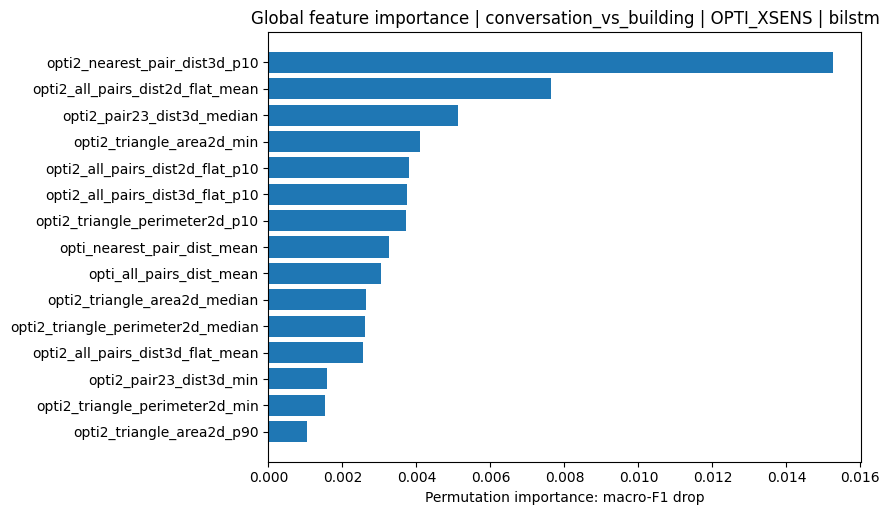

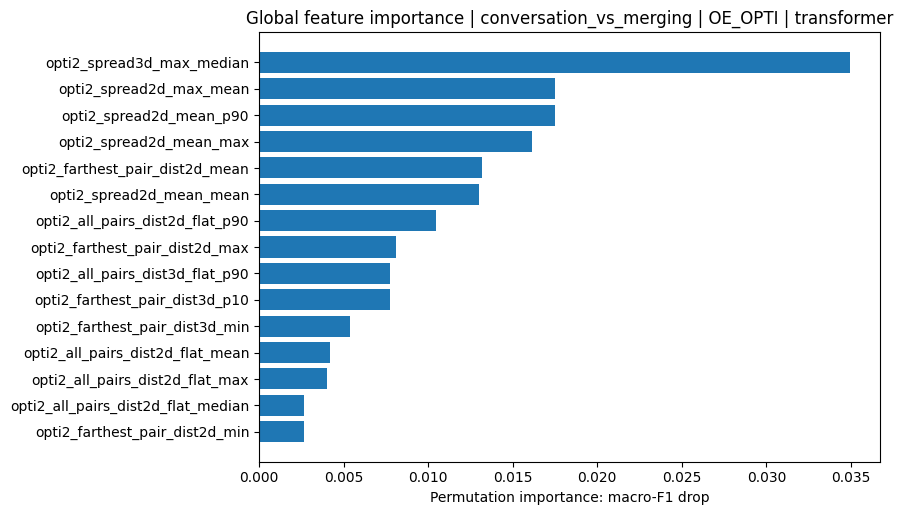

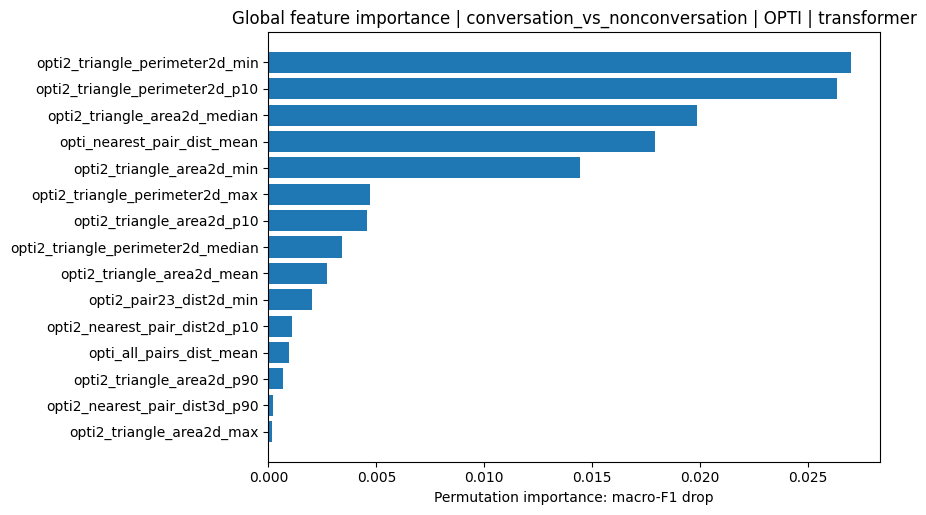

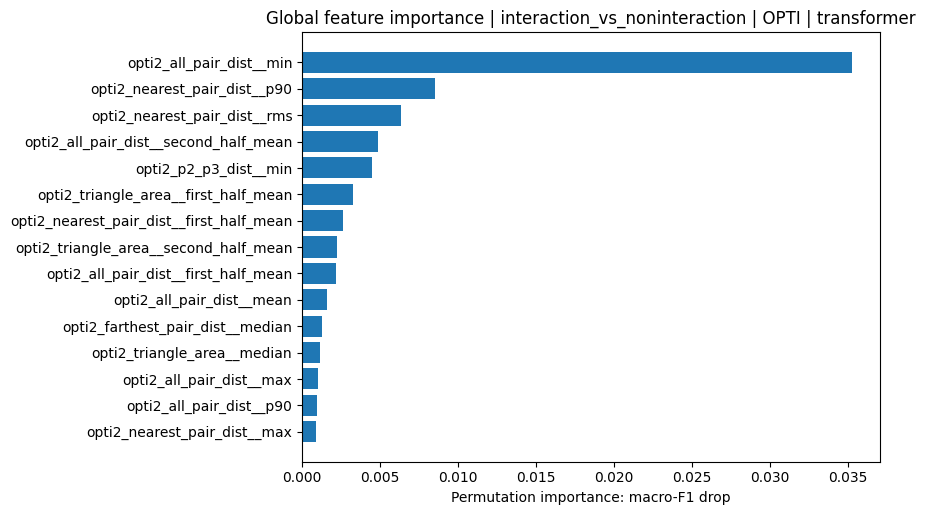

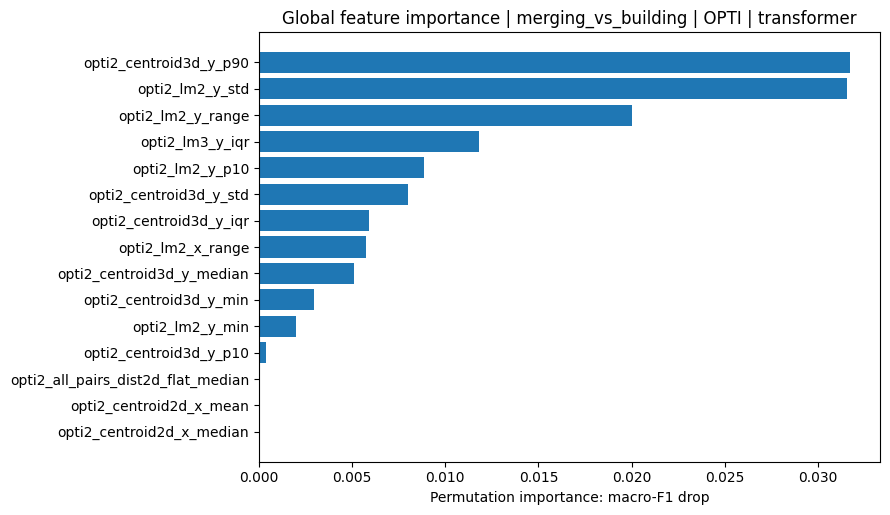

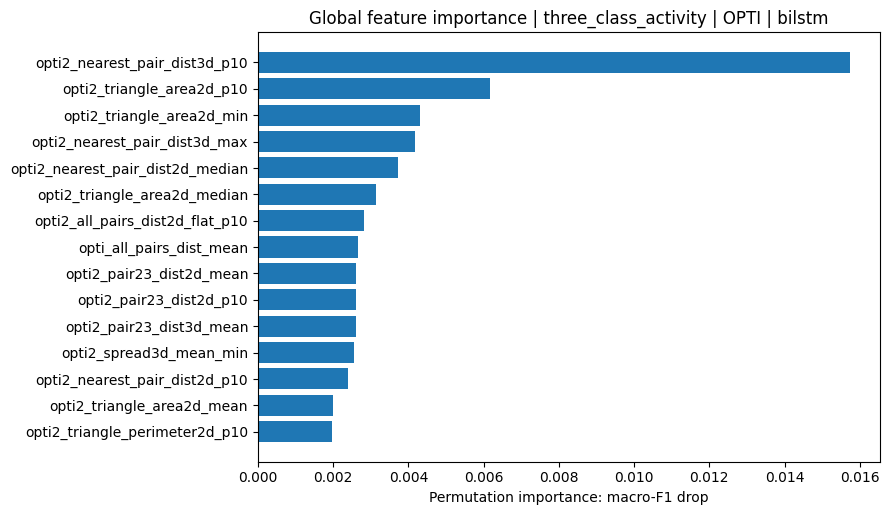

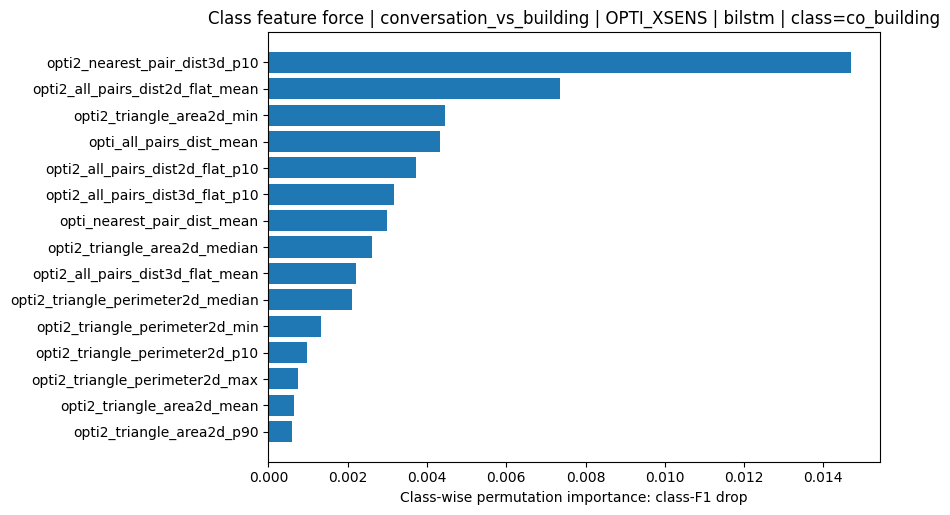

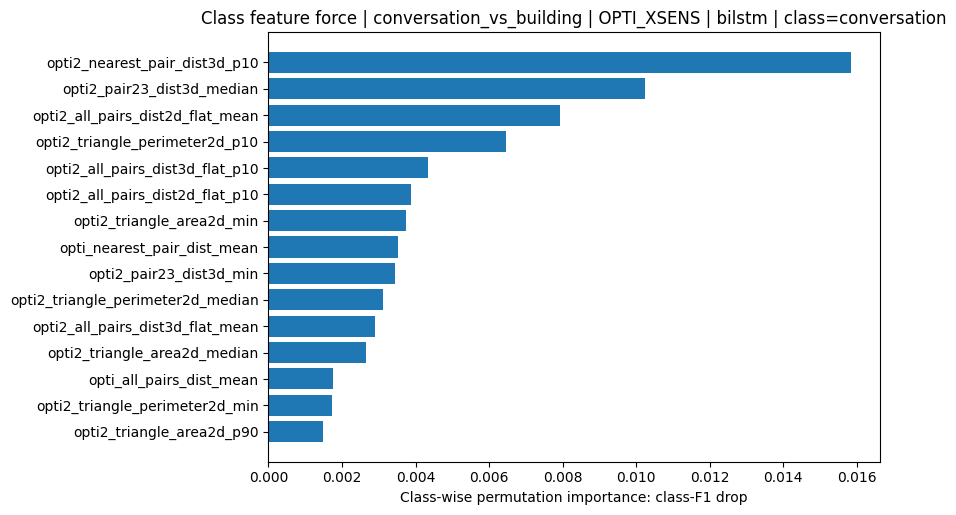

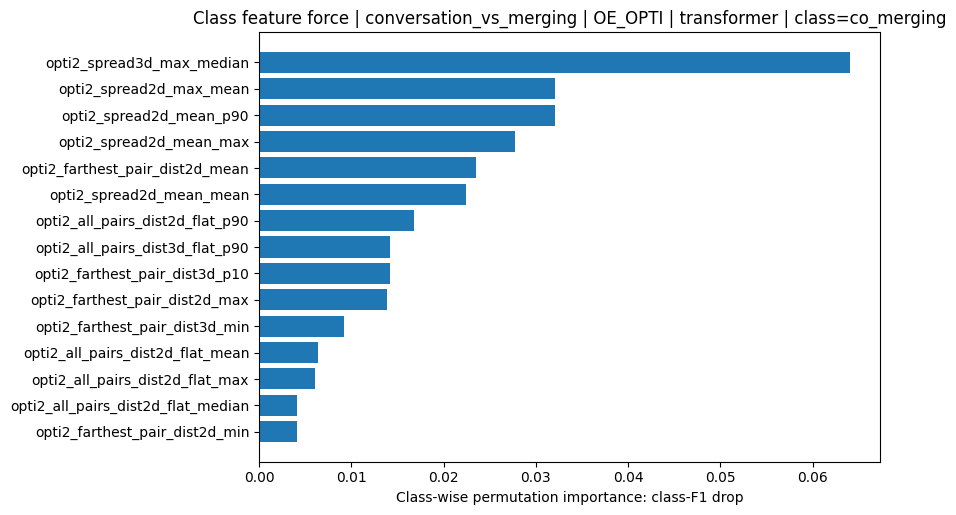

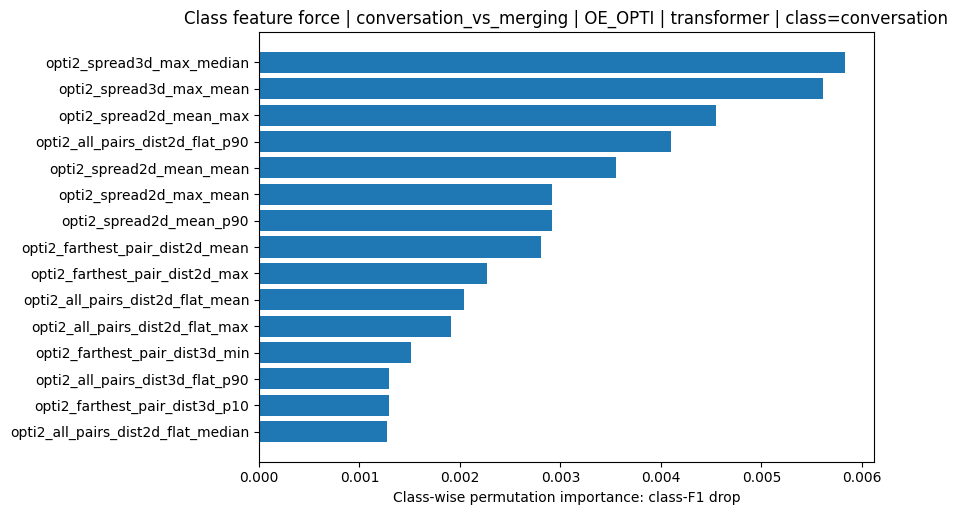

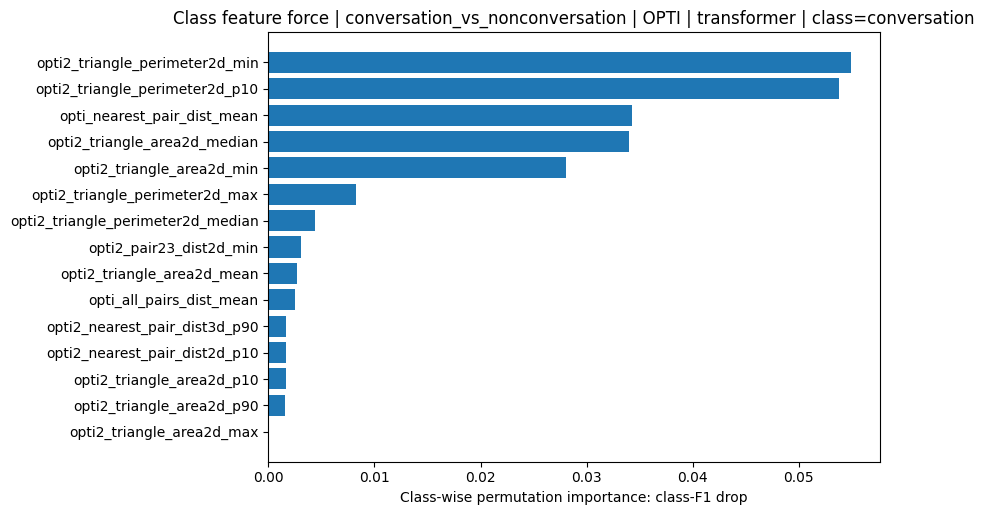

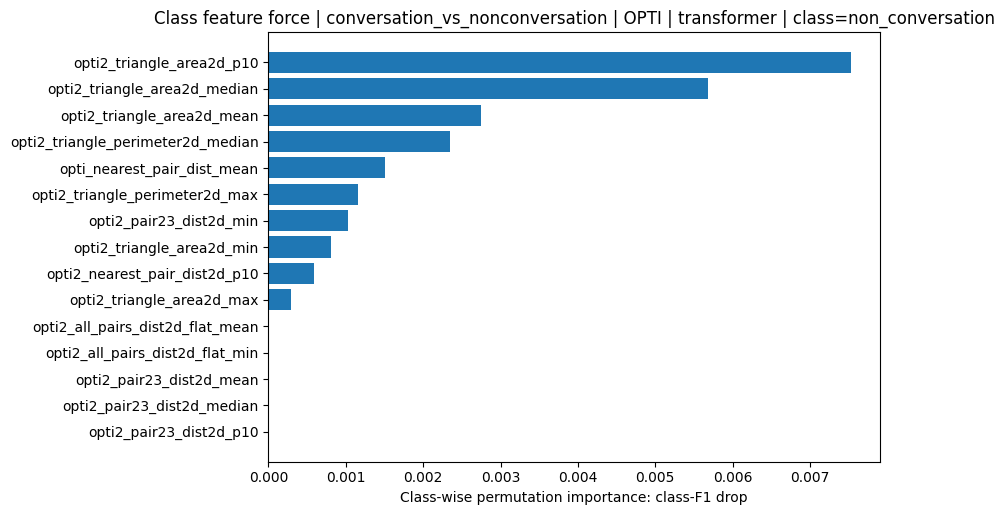

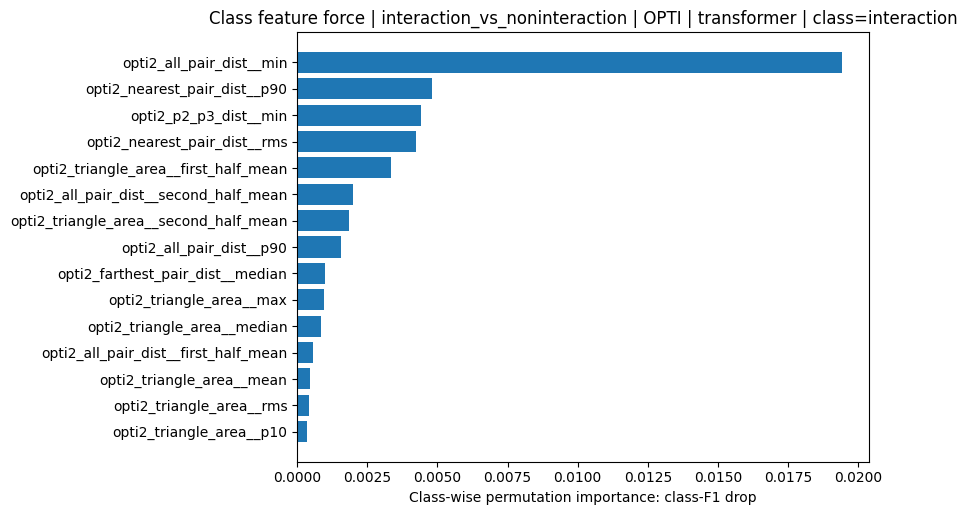

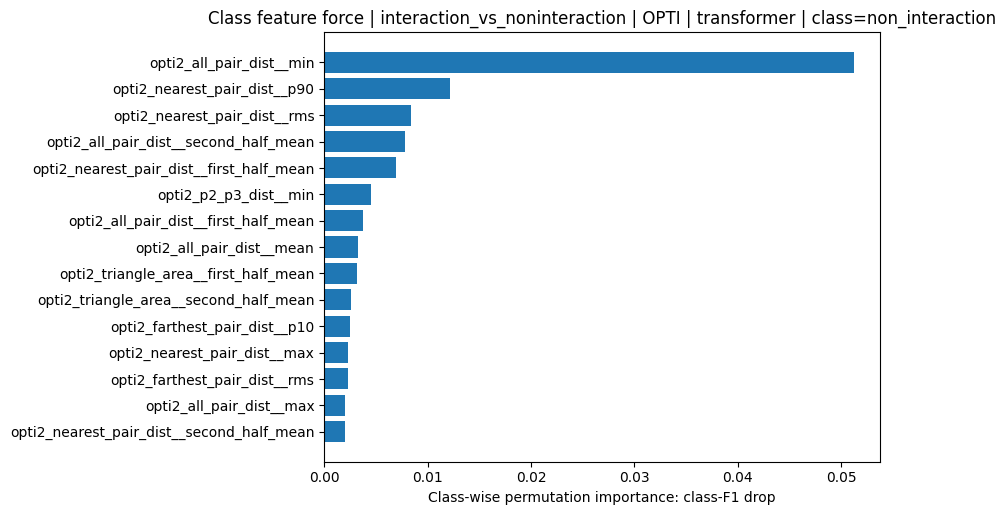

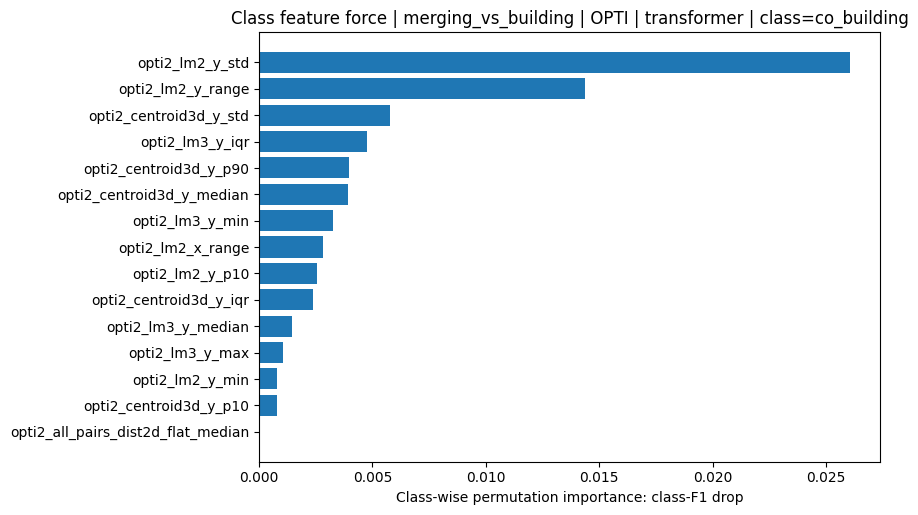

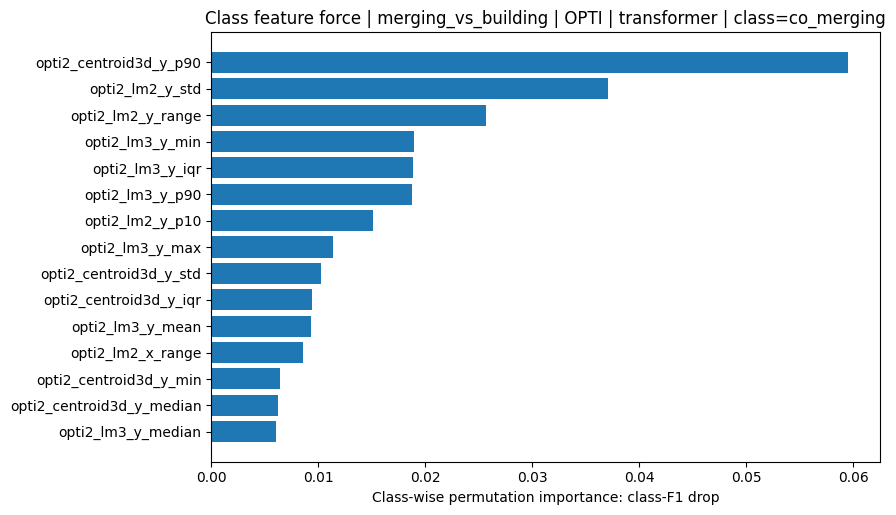

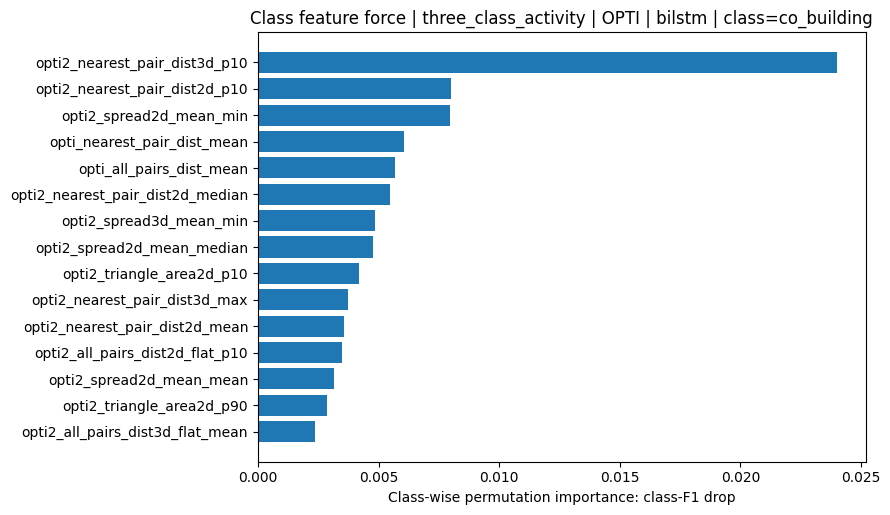

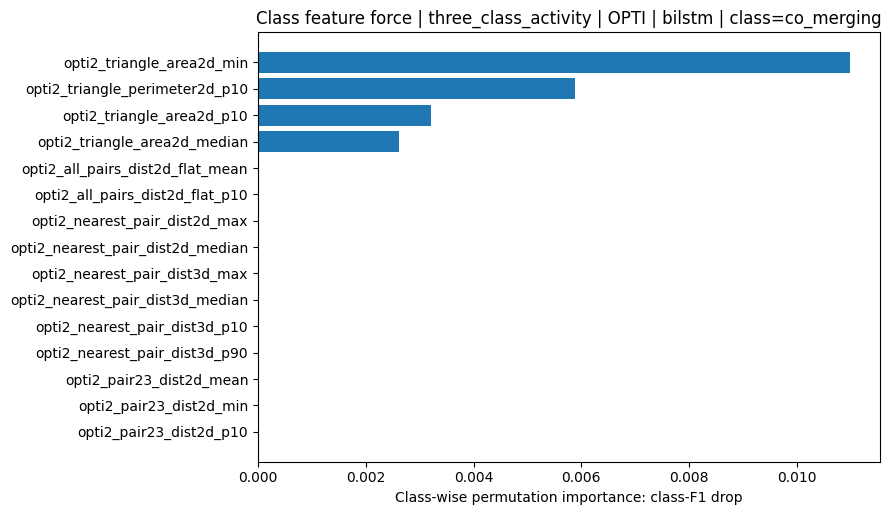

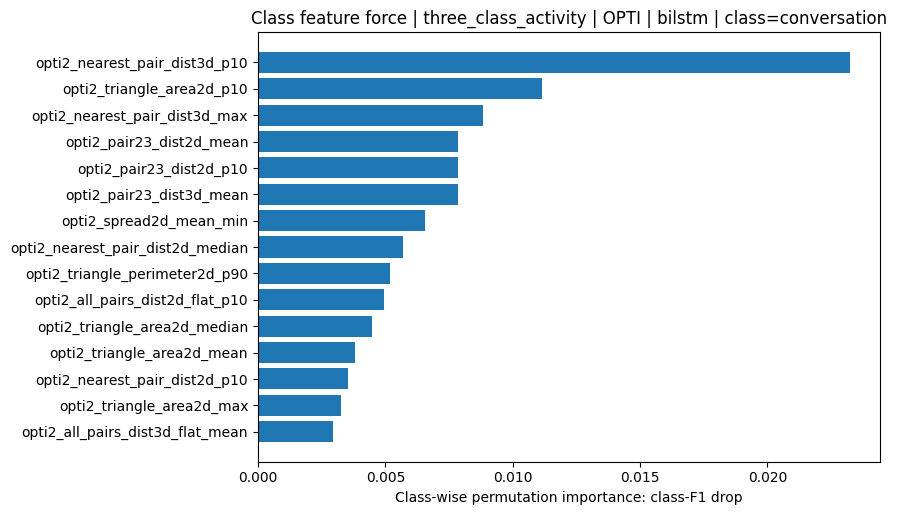


DONE.
Saved outputs in:
/content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_EXPLAINABILITY

Key output files:
- explainability_plan.csv
- fast_dl_explainability_base_overall.csv
- fast_dl_permutation_importance_global_summary.csv
- fast_dl_permutation_importance_classwise_summary.csv
- fast_dl_top_global_features_by_task_sensor.csv
- fast_dl_class_force_top_features_by_task_sensor.csv
- plots/


In [ ]:
# ================================================================
# FAST DL EXPLAINABILITY CELL
# Uses already-run FAST DL summary files to select best models.
# Then retrains only those selected models and computes:
#   1) global permutation feature importance
#   2) class-wise feature force
#   3) overall-best model highlighting
# ================================================================

import os
import glob
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# ------------------------------------------------
# SETTINGS
# ------------------------------------------------

# "all_task_sensor_bests" = explain the best DL model for every task + sensor combo.
# This can be slow because it means up to 42 models.
# "overall_best_per_task" = explain only the overall best model per task.
# This is much faster and usually enough for thesis figures.
EXPLAIN_MODE = "all_task_sensor_bests"
# EXPLAIN_MODE = "overall_best_per_task"

EXPLAIN_TASKS_TO_RUN = None
EXPLAIN_SENSOR_COMBOS_TO_RUN = None

# Full LOGO is most defensible.
# For a quick test, set this to 3.
EXPLAIN_MAX_LOGO_FOLDS = None
# EXPLAIN_MAX_LOGO_FOLDS = 3

# Speed controls for permutation importance.
EXPLAIN_MAX_FEATURES_PER_FOLD = 25
EXPLAIN_MAX_TEST_SEQUENCES_PER_FOLD = 600
EXPLAIN_PERM_REPEATS = 1

# Plot only the overall-best models, otherwise there will be too many plots.
EXPLAIN_PLOT_OVERALL_BEST_ONLY = True
EXPLAIN_PLOT_TOP_N = 15

# Use same training settings as the fast DL run.
EXPLAIN_MAX_EPOCHS = FAST_MAX_EPOCHS if "FAST_MAX_EPOCHS" in globals() else 25
EXPLAIN_PATIENCE = FAST_PATIENCE if "FAST_PATIENCE" in globals() else 4
EXPLAIN_BATCH_SIZE = FAST_BATCH_SIZE if "FAST_BATCH_SIZE" in globals() else 256
EXPLAIN_PRED_BATCH_SIZE = FAST_PRED_BATCH_SIZE if "FAST_PRED_BATCH_SIZE" in globals() else 1024

EXPLAIN_OUT_DIR = os.path.join(OUT_DIR, "FAST_DL_EXPLAINABILITY")
os.makedirs(EXPLAIN_OUT_DIR, exist_ok=True)

print("EXPLAIN_OUT_DIR:", EXPLAIN_OUT_DIR)


# ------------------------------------------------
# LOAD ALREADY-RUN FAST DL RESULTS
# ------------------------------------------------

def load_fast_dl_summaries():
    paths = sorted(glob.glob(os.path.join(OUT_DIR, "FAST_DL*", "combined_fast_dl_no_elapsed_summary.csv")))

    if "FAST_DL_OUT_DIR" in globals():
        p = os.path.join(FAST_DL_OUT_DIR, "combined_fast_dl_no_elapsed_summary.csv")
        if os.path.exists(p) and p not in paths:
            paths.append(p)

    if len(paths) == 0:
        raise FileNotFoundError(
            "No FAST DL summary files found. Run the fast DL cell first."
        )

    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["source_summary_path"] = p
        dfs.append(df)
        print("Loaded:", p, "| rows:", len(df))

    out = pd.concat(dfs, ignore_index=True)

    needed = ["task", "sensor_combo", "model_type", "seed", "seq_len", "k_features", "macro_f1", "accuracy"]
    missing = [c for c in needed if c not in out.columns]
    if missing:
        raise ValueError("Missing columns in FAST DL summary: " + str(missing))

    return out


def available_model_types():
    return sorted(set([cfg["model_type"] for cfg in MODEL_CONFIGS]))


def get_model_cfg(model_type):
    matches = [cfg for cfg in MODEL_CONFIGS if cfg["model_type"] == model_type]
    if len(matches) == 0:
        raise ValueError(
            f"Model config for {model_type} is not currently available in MODEL_CONFIGS. "
            f"Available: {available_model_types()}"
        )
    return matches[0]


def get_task_spec(task_name):
    matches = [s for s in task_specs if s["task_name"] == task_name]
    if len(matches) == 0:
        raise ValueError(f"No task spec found for {task_name}")
    return matches[0]


def make_explain_plan():
    fast = load_fast_dl_summaries()

    # Only keep models whose configs are available in the current notebook state.
    available = available_model_types()
    before = len(fast)
    fast = fast[fast["model_type"].isin(available)].copy()
    after = len(fast)

    if before != after:
        print(f"Warning: removed {before - after} rows because their model configs are not in current MODEL_CONFIGS.")
        print("Available model configs:", available)

    if EXPLAIN_TASKS_TO_RUN is not None:
        fast = fast[fast["task"].isin(EXPLAIN_TASKS_TO_RUN)].copy()

    if EXPLAIN_SENSOR_COMBOS_TO_RUN is not None:
        fast = fast[fast["sensor_combo"].isin(EXPLAIN_SENSOR_COMBOS_TO_RUN)].copy()

    # Best fast DL model per task + sensor combination.
    best_task_sensor = (
        fast
        .sort_values(["task", "sensor_combo", "macro_f1", "accuracy"],
                     ascending=[True, True, False, False])
        .groupby(["task", "sensor_combo"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    # Overall best model per task.
    overall_best = (
        best_task_sensor
        .sort_values(["task", "macro_f1", "accuracy"],
                     ascending=[True, False, False])
        .groupby("task", as_index=False)
        .head(1)
        .loc[:, ["task", "sensor_combo", "model_type", "macro_f1", "accuracy"]]
        .rename(columns={
            "sensor_combo": "overall_best_sensor_combo",
            "model_type": "overall_best_model_type",
            "macro_f1": "overall_best_macro_f1",
            "accuracy": "overall_best_accuracy",
        })
    )

    plan = best_task_sensor.merge(overall_best, on="task", how="left")

    plan["is_overall_best_for_task"] = (
        (plan["sensor_combo"] == plan["overall_best_sensor_combo"]) &
        (plan["model_type"] == plan["overall_best_model_type"]) &
        (np.isclose(plan["macro_f1"], plan["overall_best_macro_f1"]))
    )

    if EXPLAIN_MODE == "overall_best_per_task":
        plan = plan[plan["is_overall_best_for_task"]].copy()
    elif EXPLAIN_MODE != "all_task_sensor_bests":
        raise ValueError("EXPLAIN_MODE must be 'all_task_sensor_bests' or 'overall_best_per_task'.")

    return plan.reset_index(drop=True)


def highlight_overall_best(row):
    if bool(row.get("is_overall_best_for_task", False)):
        return ["background-color: #fff3b0"] * len(row)
    return [""] * len(row)


# ------------------------------------------------
# PREDICTION HELPER
# ------------------------------------------------

def predict_dl(model, X, batch_size=EXPLAIN_PRED_BATCH_SIZE):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            preds.extend(logits.argmax(1).cpu().numpy())

    return np.array(preds)


def per_class_f1(y_true, y_pred, n_classes):
    return f1_score(
        y_true,
        y_pred,
        labels=list(range(n_classes)),
        average=None,
        zero_division=0
    )


# ------------------------------------------------
# EXPLAIN ONE MODEL
# ------------------------------------------------

def explain_one_fast_model(row):
    task_name = row["task"]
    sensor_combo = row["sensor_combo"]
    model_type = row["model_type"]
    seed = int(row["seed"])
    seq_len = int(row["seq_len"])
    k_features = int(row["k_features"])

    spec = get_task_spec(task_name)
    model_cfg = get_model_cfg(model_type)

    set_seed(seed)

    df = spec["df"].copy()
    feature_list = spec["combo_features"][sensor_combo].copy()

    label_order = spec["label_order"]
    n_classes = len(label_order)

    label_to_id = {lab: i for i, lab in enumerate(label_order)}
    id_to_label = {i: lab for lab, i in label_to_id.items()}

    y_label = df[spec["target_col"]].astype(str).values
    y_all = np.array([label_to_id[v] for v in y_label], dtype=int)

    groups_all = df[spec["group_col"]].values
    starts_all = pd.to_numeric(df[spec["start_col"]], errors="coerce").values
    X_raw = df[feature_list].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()

    base_true_all = []
    base_pred_all = []

    base_rows = []
    global_rows = []
    class_rows = []

    rng = np.random.default_rng(seed)
    fold_counter = 0
    t0 = time.time()

    for fold, (trval_idx, te_idx) in enumerate(logo.split(X_raw, y_all, groups_all), start=1):
        fold_counter += 1

        if EXPLAIN_MAX_LOGO_FOLDS is not None and fold_counter > EXPLAIN_MAX_LOGO_FOLDS:
            break

        if len(np.unique(y_all[trval_idx])) < 2:
            continue

        test_group = groups_all[te_idx][0]

        train_groups = np.unique(groups_all[trval_idx])
        val_group = choose_validation_group(train_groups, y_all, groups_all)

        val_mask = groups_all[trval_idx] == val_group
        val_idx = trval_idx[val_mask]
        tr_idx = trval_idx[~val_mask]

        if len(np.unique(y_all[tr_idx])) < 2:
            continue

        # Preprocess
        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        original_feature_names = np.array(feature_list)

        Xtr_raw = X_raw[tr_idx]
        Xval_raw = X_raw[val_idx]
        Xte_raw = X_raw[te_idx]

        Xtr = imputer.fit_transform(Xtr_raw)
        Xval = imputer.transform(Xval_raw)
        Xte = imputer.transform(Xte_raw)

        # SimpleImputer may drop columns that are fully missing in the training fold.
        # Therefore we must update the feature names after imputation.
        try:
            imputed_feature_names = imputer.get_feature_names_out(original_feature_names)
        except Exception:
            kept_mask = ~np.all(pd.isna(Xtr_raw), axis=0)
            imputed_feature_names = original_feature_names[kept_mask]

        imputed_feature_names = np.array(imputed_feature_names)

        # Safety check
        if len(imputed_feature_names) != Xtr.shape[1]:
            print("WARNING: feature-name length mismatch after imputation.")
            print("len(imputed_feature_names):", len(imputed_feature_names))
            print("Xtr.shape[1]:", Xtr.shape[1])
            imputed_feature_names = np.array([f"feature_{i}" for i in range(Xtr.shape[1])])

        Xtr = scaler.fit_transform(Xtr)
        Xval = scaler.transform(Xval)
        Xte = scaler.transform(Xte)

        actual_k = min(k_features, Xtr.shape[1])

        selector = SelectKBest(f_classif, k=actual_k)
        Xtr = selector.fit_transform(Xtr, y_all[tr_idx])
        Xval = selector.transform(Xval)
        Xte = selector.transform(Xte)

        selected_mask = selector.get_support()

        # Use imputed_feature_names, not the original feature_list
        selected_names = imputed_feature_names[selected_mask]

        selected_scores = selector.scores_[selected_mask]
        selected_scores = np.nan_to_num(selected_scores, nan=-np.inf, posinf=np.inf, neginf=-np.inf)

        # Make sequences
        Xtr_seq, ytr_seq, _, _ = make_sequences(
            Xtr, y_all[tr_idx], groups_all[tr_idx], starts_all[tr_idx], seq_len
        )
        Xval_seq, yval_seq, _, _ = make_sequences(
            Xval, y_all[val_idx], groups_all[val_idx], starts_all[val_idx], seq_len
        )
        Xte_seq, yte_seq, _, _ = make_sequences(
            Xte, y_all[te_idx], groups_all[te_idx], starts_all[te_idx], seq_len
        )

        if len(Xtr_seq) == 0 or len(Xval_seq) == 0 or len(Xte_seq) == 0:
            continue

        # Train selected best fast model
        model = build_model(model_cfg, input_dim=actual_k, n_classes=n_classes).to(DEVICE)

        opt = torch.optim.AdamW(
            model.parameters(),
            lr=model_cfg["lr"],
            weight_decay=model_cfg["weight_decay"]
        )

        loss_fn = nn.CrossEntropyLoss()
        train_loader = make_loader(Xtr_seq, ytr_seq, EXPLAIN_BATCH_SIZE, shuffle=True)

        best_state = None
        best_val_macro = -1
        patience_left = EXPLAIN_PATIENCE
        best_epoch = 0

        for epoch in range(1, EXPLAIN_MAX_EPOCHS + 1):
            model.train()

            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            val_pred = predict_dl(model, Xval_seq)
            val_macro = f1_score(yval_seq, val_pred, average="macro", zero_division=0)

            if val_macro > best_val_macro:
                best_val_macro = val_macro
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_left = EXPLAIN_PATIENCE
                best_epoch = epoch
            else:
                patience_left -= 1

            if patience_left <= 0:
                break

        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(DEVICE)

        # Base test performance
        base_pred = predict_dl(model, Xte_seq)

        base_true_all.extend(yte_seq.tolist())
        base_pred_all.extend(base_pred.tolist())

        base_acc = accuracy_score(yte_seq, base_pred)
        base_macro = f1_score(yte_seq, base_pred, average="macro", zero_division=0)
        base_bal = balanced_accuracy_score(yte_seq, base_pred)

        base_rows.append({
            "task": task_name,
            "sensor_combo": sensor_combo,
            "model_type": model_type,
            "seed": seed,
            "seq_len": seq_len,
            "k_features": k_features,
            "fold": fold,
            "test_group": test_group,
            "n_test_sequences": len(Xte_seq),
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro,
            "base_accuracy": base_acc,
            "base_macro_f1": base_macro,
            "base_balanced_accuracy": base_bal,
            "is_overall_best_for_task": bool(row["is_overall_best_for_task"]),
        })

        # Choose features to test by univariate selector score
        order = np.argsort(selected_scores)[::-1]
        if EXPLAIN_MAX_FEATURES_PER_FOLD is not None:
            order = order[:min(EXPLAIN_MAX_FEATURES_PER_FOLD, len(order))]

        # Subsample test sequences for faster permutation
        if EXPLAIN_MAX_TEST_SEQUENCES_PER_FOLD is not None and len(Xte_seq) > EXPLAIN_MAX_TEST_SEQUENCES_PER_FOLD:
            eval_idx = rng.choice(len(Xte_seq), size=EXPLAIN_MAX_TEST_SEQUENCES_PER_FOLD, replace=False)
            X_eval = Xte_seq[eval_idx].copy()
            y_eval = yte_seq[eval_idx].copy()
        else:
            X_eval = Xte_seq.copy()
            y_eval = yte_seq.copy()

        base_eval_pred = predict_dl(model, X_eval)
        base_eval_acc = accuracy_score(y_eval, base_eval_pred)
        base_eval_macro = f1_score(y_eval, base_eval_pred, average="macro", zero_division=0)
        base_eval_class_f1 = per_class_f1(y_eval, base_eval_pred, n_classes)

        # Permutation importance
        for rank, j in enumerate(order, start=1):
            feature_name = str(selected_names[j])

            drops_acc = []
            drops_macro = []
            drops_class = []

            for rep in range(EXPLAIN_PERM_REPEATS):
                X_perm = X_eval.copy()

                # Shuffle feature trace across sequences
                perm_idx = rng.permutation(len(X_perm))
                X_perm[:, :, j] = X_perm[perm_idx, :, j]

                perm_pred = predict_dl(model, X_perm)

                perm_acc = accuracy_score(y_eval, perm_pred)
                perm_macro = f1_score(y_eval, perm_pred, average="macro", zero_division=0)
                perm_class_f1 = per_class_f1(y_eval, perm_pred, n_classes)

                drops_acc.append(base_eval_acc - perm_acc)
                drops_macro.append(base_eval_macro - perm_macro)
                drops_class.append(base_eval_class_f1 - perm_class_f1)

            mean_class_drop = np.mean(np.stack(drops_class), axis=0)

            global_rows.append({
                "task": task_name,
                "sensor_combo": sensor_combo,
                "model_type": model_type,
                "seed": seed,
                "seq_len": seq_len,
                "k_features": k_features,
                "fold": fold,
                "test_group": test_group,
                "feature": feature_name,
                "rank_within_fold_by_f_score": rank,
                "selector_f_score": float(selected_scores[j]) if np.isfinite(selected_scores[j]) else np.nan,
                "n_eval_sequences": len(X_eval),
                "base_eval_accuracy": base_eval_acc,
                "base_eval_macro_f1": base_eval_macro,
                "accuracy_drop": float(np.mean(drops_acc)),
                "macro_f1_drop": float(np.mean(drops_macro)),
                "is_overall_best_for_task": bool(row["is_overall_best_for_task"]),
            })

            for class_idx, class_label in enumerate(label_order):
                class_rows.append({
                    "task": task_name,
                    "sensor_combo": sensor_combo,
                    "model_type": model_type,
                    "seed": seed,
                    "seq_len": seq_len,
                    "k_features": k_features,
                    "fold": fold,
                    "test_group": test_group,
                    "class_label": class_label,
                    "feature": feature_name,
                    "rank_within_fold_by_f_score": rank,
                    "selector_f_score": float(selected_scores[j]) if np.isfinite(selected_scores[j]) else np.nan,
                    "n_eval_sequences": len(X_eval),
                    "base_class_f1": float(base_eval_class_f1[class_idx]),
                    "class_f1_drop": float(mean_class_drop[class_idx]),
                    "is_overall_best_for_task": bool(row["is_overall_best_for_task"]),
                })

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(base_true_all) == 0:
        return None, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    base_true_all = np.array(base_true_all)
    base_pred_all = np.array(base_pred_all)

    overall_row = {
        "task": task_name,
        "sensor_combo": sensor_combo,
        "model_type": model_type,
        "seed": seed,
        "seq_len": seq_len,
        "k_features": k_features,
        "n_sequences": len(base_true_all),
        "accuracy": accuracy_score(base_true_all, base_pred_all),
        "macro_f1": f1_score(base_true_all, base_pred_all, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(base_true_all, base_pred_all),
        "runtime_minutes": (time.time() - t0) / 60,
        "is_overall_best_for_task": bool(row["is_overall_best_for_task"]),
    }

    return overall_row, pd.DataFrame(base_rows), pd.DataFrame(global_rows), pd.DataFrame(class_rows)


# ------------------------------------------------
# RUN EXPLAINABILITY
# ------------------------------------------------

explain_plan = make_explain_plan()

print("=" * 100)
print("EXPLAINABILITY PLAN")
print("=" * 100)
print("Number of models to explain:", len(explain_plan))

display_cols = [
    "task", "sensor_combo", "model_type", "seed", "seq_len", "k_features",
    "accuracy", "macro_f1", "is_overall_best_for_task"
]

display(
    explain_plan[display_cols]
    .round(4)
    .style.apply(highlight_overall_best, axis=1)
)

explain_plan.to_csv(os.path.join(EXPLAIN_OUT_DIR, "explainability_plan.csv"), index=False)

all_overall_rows = []
all_base_dfs = []
all_global_dfs = []
all_class_dfs = []

t0_all = time.time()

for i, row in explain_plan.iterrows():
    print("\n" + "#" * 120)
    print(
        f"EXPLAIN {i + 1}/{len(explain_plan)} | "
        f"{row['task']} | {row['sensor_combo']} | {row['model_type']} | "
        f"seq_len={int(row['seq_len'])} | k={int(row['k_features'])} | "
        f"overall_best={bool(row['is_overall_best_for_task'])}"
    )
    print("#" * 120)

    run_t0 = time.time()

    overall_row, base_df, global_df, class_df = explain_one_fast_model(row)

    if overall_row is not None:
        all_overall_rows.append(overall_row)

    if len(base_df) > 0:
        all_base_dfs.append(base_df)

    if len(global_df) > 0:
        all_global_dfs.append(global_df)

    if len(class_df) > 0:
        all_class_dfs.append(class_df)

    # Save incrementally
    if len(all_overall_rows) > 0:
        pd.DataFrame(all_overall_rows).to_csv(
            os.path.join(EXPLAIN_OUT_DIR, "fast_dl_explainability_base_overall.csv"),
            index=False
        )

    if len(all_base_dfs) > 0:
        pd.concat(all_base_dfs, ignore_index=True).to_csv(
            os.path.join(EXPLAIN_OUT_DIR, "fast_dl_explainability_base_by_fold.csv"),
            index=False
        )

    if len(all_global_dfs) > 0:
        pd.concat(all_global_dfs, ignore_index=True).to_csv(
            os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_global_raw.csv"),
            index=False
        )

    if len(all_class_dfs) > 0:
        pd.concat(all_class_dfs, ignore_index=True).to_csv(
            os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_classwise_raw.csv"),
            index=False
        )

    elapsed = (time.time() - t0_all) / 60
    run_minutes = (time.time() - run_t0) / 60
    avg = elapsed / max(1, i + 1)
    remaining = len(explain_plan) - (i + 1)

    print(f"Run time: {run_minutes:.1f} min")
    print(f"Elapsed: {elapsed:.1f} min")
    print(f"Estimated remaining: {remaining * avg:.1f} min")


# ------------------------------------------------
# AGGREGATE RESULTS
# ------------------------------------------------

base_overall = pd.DataFrame(all_overall_rows)

global_raw = (
    pd.concat(all_global_dfs, ignore_index=True)
    if len(all_global_dfs) > 0
    else pd.DataFrame()
)

class_raw = (
    pd.concat(all_class_dfs, ignore_index=True)
    if len(all_class_dfs) > 0
    else pd.DataFrame()
)

if len(base_overall) > 0:
    base_overall = (
        base_overall
        .sort_values(["task", "macro_f1", "accuracy"], ascending=[True, False, False])
        .reset_index(drop=True)
    )

    base_overall.to_csv(
        os.path.join(EXPLAIN_OUT_DIR, "fast_dl_explainability_base_overall.csv"),
        index=False
    )

    print("\n" + "=" * 100)
    print("BASE PERFORMANCE OF EXPLAINED MODELS")
    print("=" * 100)

    display(
        base_overall
        .round(4)
        .style.apply(highlight_overall_best, axis=1)
    )

if len(global_raw) > 0:
    global_summary = (
        global_raw
        .groupby(["task", "sensor_combo", "model_type", "feature", "is_overall_best_for_task"], as_index=False)
        .agg(
            mean_macro_f1_drop=("macro_f1_drop", "mean"),
            std_macro_f1_drop=("macro_f1_drop", "std"),
            mean_accuracy_drop=("accuracy_drop", "mean"),
            mean_selector_f_score=("selector_f_score", "mean"),
            n_folds=("fold", "nunique"),
            n_rows=("macro_f1_drop", "size"),
        )
        .sort_values(["task", "sensor_combo", "mean_macro_f1_drop"],
                     ascending=[True, True, False])
        .reset_index(drop=True)
    )

    global_summary.to_csv(
        os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_global_summary.csv"),
        index=False
    )

    top_global = (
        global_summary
        .sort_values(["task", "sensor_combo", "mean_macro_f1_drop"],
                     ascending=[True, True, False])
        .groupby(["task", "sensor_combo", "model_type"], as_index=False)
        .head(EXPLAIN_PLOT_TOP_N)
        .reset_index(drop=True)
    )

    top_global.to_csv(
        os.path.join(EXPLAIN_OUT_DIR, "fast_dl_top_global_features_by_task_sensor.csv"),
        index=False
    )

    print("\n" + "=" * 100)
    print("TOP GLOBAL FEATURES BY MACRO-F1 DROP")
    print("=" * 100)

    display(
        top_global
        .head(80)
        .round(5)
        .style.apply(highlight_overall_best, axis=1)
    )

if len(class_raw) > 0:
    class_summary = (
        class_raw
        .groupby(["task", "sensor_combo", "model_type", "class_label", "feature", "is_overall_best_for_task"], as_index=False)
        .agg(
            mean_class_f1_drop=("class_f1_drop", "mean"),
            std_class_f1_drop=("class_f1_drop", "std"),
            mean_base_class_f1=("base_class_f1", "mean"),
            mean_selector_f_score=("selector_f_score", "mean"),
            n_folds=("fold", "nunique"),
            n_rows=("class_f1_drop", "size"),
        )
        .sort_values(["task", "sensor_combo", "class_label", "mean_class_f1_drop"],
                     ascending=[True, True, True, False])
        .reset_index(drop=True)
    )

    class_summary.to_csv(
        os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_classwise_summary.csv"),
        index=False
    )

    class_force_top = (
        class_summary
        .sort_values(["task", "sensor_combo", "class_label", "mean_class_f1_drop"],
                     ascending=[True, True, True, False])
        .groupby(["task", "sensor_combo", "model_type", "class_label"], as_index=False)
        .head(EXPLAIN_PLOT_TOP_N)
        .reset_index(drop=True)
    )

    class_force_top.to_csv(
        os.path.join(EXPLAIN_OUT_DIR, "fast_dl_class_force_top_features_by_task_sensor.csv"),
        index=False
    )

    print("\n" + "=" * 100)
    print("CLASS-WISE FEATURE FORCE")
    print("=" * 100)

    display(
        class_force_top
        .head(100)
        .round(5)
        .style.apply(highlight_overall_best, axis=1)
    )


# ------------------------------------------------
# PLOTS FOR OVERALL-BEST MODELS
# ------------------------------------------------

plot_dir = os.path.join(EXPLAIN_OUT_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

def safe_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(":", "_")

if len(global_raw) > 0:
    plot_source = global_summary.copy()

    if EXPLAIN_PLOT_OVERALL_BEST_ONLY:
        plot_source = plot_source[plot_source["is_overall_best_for_task"] == True].copy()

    for (task, sensor_combo, model_type), sub in plot_source.groupby(["task", "sensor_combo", "model_type"]):
        sub = sub.sort_values("mean_macro_f1_drop", ascending=False).head(EXPLAIN_PLOT_TOP_N)

        if len(sub) == 0:
            continue

        plt.figure(figsize=(9, max(4, 0.35 * len(sub))))
        plt.barh(sub["feature"][::-1], sub["mean_macro_f1_drop"][::-1])
        plt.xlabel("Permutation importance: macro-F1 drop")
        plt.title(f"Global feature importance | {task} | {sensor_combo} | {model_type}")
        plt.tight_layout()

        out_path = os.path.join(
            plot_dir,
            f"global_importance_{safe_name(task)}_{safe_name(sensor_combo)}_{safe_name(model_type)}.png"
        )

        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()

if len(class_raw) > 0:
    plot_source = class_summary.copy()

    if EXPLAIN_PLOT_OVERALL_BEST_ONLY:
        plot_source = plot_source[plot_source["is_overall_best_for_task"] == True].copy()

    for (task, sensor_combo, model_type, class_label), sub in plot_source.groupby(
        ["task", "sensor_combo", "model_type", "class_label"]
    ):
        sub = sub.sort_values("mean_class_f1_drop", ascending=False).head(EXPLAIN_PLOT_TOP_N)

        if len(sub) == 0:
            continue

        plt.figure(figsize=(9, max(4, 0.35 * len(sub))))
        plt.barh(sub["feature"][::-1], sub["mean_class_f1_drop"][::-1])
        plt.xlabel("Class-wise permutation importance: class-F1 drop")
        plt.title(f"Class feature force | {task} | {sensor_combo} | {model_type} | class={class_label}")
        plt.tight_layout()

        out_path = os.path.join(
            plot_dir,
            f"class_force_{safe_name(task)}_{safe_name(sensor_combo)}_{safe_name(model_type)}_{safe_name(class_label)}.png"
        )

        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()

print("\nDONE.")
print("Saved outputs in:")
print(EXPLAIN_OUT_DIR)
print("\nKey output files:")
print("- explainability_plan.csv")
print("- fast_dl_explainability_base_overall.csv")
print("- fast_dl_permutation_importance_global_summary.csv")
print("- fast_dl_permutation_importance_classwise_summary.csv")
print("- fast_dl_top_global_features_by_task_sensor.csv")
print("- fast_dl_class_force_top_features_by_task_sensor.csv")
print("- plots/")

Reading explainability outputs from:
/content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_EXPLAINABILITY

Saving OE-only summaries to:
/content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_EXPLAINABILITY/OE_ONLY_SUMMARY

Loaded files:
Plan rows: 42
Base performance rows: 42
Global importance rows: 2242
Class-wise importance rows: 4841

OE-ONLY BEST FAST DL MODELS PER TASK


,task,sensor_combo,model_type,seq_len,k_features,fast_dl_summary_accuracy,fast_dl_summary_macro_f1,explainability_rerun_accuracy,explainability_rerun_macro_f1,explainability_rerun_balanced_accuracy,is_overall_best_among_all_sensors
0,conversation_vs_building,OE,transformer,9,120,0.7560,0.6972,0.6976,0.6297,0.6258,False
1,conversation_vs_merging,OE,bilstm,9,120,0.6640,0.6575,0.6720,0.6682,0.6981,False
2,conversation_vs_nonconversation,OE,transformer,9,120,0.7370,0.6472,0.7391,0.6552,0.6523,False
3,interaction_vs_noninteraction,OE,bilstm,18,120,0.5450,0.5443,0.5230,0.5230,0.5230,False
4,merging_vs_building,OE,gru,9,120,0.6650,0.5711,0.6929,0.6150,0.6437,False
5,three_class_activity,OE,bilstm,9,120,0.5978,0.4892,0.4152,0.3467,0.3534,False



OE GLOBAL FEATURE IMPORTANCE
Higher mean_macro_f1_drop means the feature was more important.


,task,model_type,feature,mean_macro_f1_drop,mean_accuracy_drop,mean_selector_f_score,n_folds
0,conversation_vs_building,transformer,oe__oe_acc_active_count_mean,0.01235,0.00532,101.54968,2
1,conversation_vs_building,transformer,oe__oe_turn_rate_p75_min,0.00689,-0.00070,115.43440,5
2,conversation_vs_building,transformer,oe__oe_turn_rate_p75_mean,0.00632,0.00038,128.27056,8
3,conversation_vs_building,transformer,oe__oe_acc_energy_range_min,0.00559,0.00526,98.91836,2
4,conversation_vs_building,transformer,oe__oe_gyro_energy_maddiff_mean,0.00519,0.00078,164.88975,9
5,conversation_vs_building,transformer,oe__oe_jerk_abs_mean_min,0.00458,0.00366,118.93134,7
6,conversation_vs_building,transformer,oe__mag_magnitude_z_maddiff_min,0.00441,0.00343,95.26425,5
7,conversation_vs_building,transformer,oe__mag_magnitude_z_mean_mean,0.00297,0.00532,120.13146,2
8,conversation_vs_building,transformer,oe__mag_magnitude_z_range_min,0.00297,0.00532,137.88397,2
9,conversation_vs_building,transformer,oe__mag_magnitude_vel_abs_std_min,0.00284,0.00200,104.07681,7



OE CLASS-WISE FEATURE FORCE
Higher mean_class_f1_drop means the feature was more important for that class.


,task,model_type,class_label,feature,mean_class_f1_drop,mean_base_class_f1,mean_selector_f_score,n_folds
0,conversation_vs_building,transformer,co_building,oe__mag_magnitude_z_mean_mean,0.00436,0.80099,120.13146,2
1,conversation_vs_building,transformer,co_building,oe__mag_magnitude_z_range_min,0.00436,0.51758,137.88397,2
2,conversation_vs_building,transformer,co_building,oe__oe_acc_energy_range_min,0.00398,0.57507,98.91836,2
3,conversation_vs_building,transformer,co_building,oe__oe_acc_active_count_mean,0.00255,0.80232,101.54968,2
4,conversation_vs_building,transformer,co_building,oe__mag_magnitude_z_maddiff_min,0.00243,0.85940,95.26425,5
5,conversation_vs_building,transformer,co_building,oe__mag_magnitude_z_mean_min,0.00218,0.84116,112.50966,4
6,conversation_vs_building,transformer,co_building,oe__oe_gyro_energy_maddiff_mean,0.00168,0.67885,164.88975,9
7,conversation_vs_building,transformer,co_building,oe__mag_magnitude_vel_abs_std_min,0.00161,0.82483,104.07681,7
8,conversation_vs_building,transformer,co_building,oe__mag_magnitude_vel_abs_mean_min,0.00089,0.85940,97.43314,5
9,conversation_vs_building,transformer,co_building,oe__mag_magnitude_vel_abs_mean_mean,0.00043,0.72741,103.48402,8



COMPACT OE INTERPRETATION TABLE


,task,best_oe_model,oe_accuracy,oe_macro_f1,top_5_oe_explanatory_features
0,conversation_vs_building,transformer,0.7560,0.6972,oe__oe_acc_active_count_mean; oe__oe_turn_rate_p75_min; oe__oe_turn_rate_p75_mean; oe__oe_acc_energy_range_min; oe__oe_gyro_energy_maddiff_mean
1,conversation_vs_merging,bilstm,0.6640,0.6575,oe__oe_gyro_active_count_switch_rate; oe__mag_magnitude_high_band_max; oe__mag_magnitude_entropy_mean; oe__oe_turn_rate_p75_asymmetry; oe__oe_gyro_active_count_mean
2,conversation_vs_nonconversation,transformer,0.7370,0.6472,oe__oe_gyro_energy_iqr_asymmetry; oe__mag_magnitude_z_std_mean; oe__oe_angular_jerk_abs_mean_min; oe__oe_turn_rate_p90_min; oe__ear_head_turn_event_rate
3,interaction_vs_noninteraction,bilstm,0.5450,0.5443,oe_head_posture_switch_frequency_max; oe_turn_rate_p90_max; oe_jerk_abs_std_max; oe_down_count_switch_rate; oe_jerk_abs_mean_mean
4,merging_vs_building,gru,0.6650,0.5711,oe__oe_pair_gyro_corr_std; oe__mag_magnitude_z_mean_min; oe__oe_acc_active_count_mean; oe__oe_jerk_abs_std_min; oe__oe_acc_e_half_delta_range
5,three_class_activity,bilstm,0.5978,0.4892,oe__oe_angular_jerk_abs_mean_min; oe__oe_acc_active_count_all3_frac; oe__mag_magnitude_z_mean_mean; oe__oe_acc_energy_range_min; oe__oe_turn_rate_p75_mean



Creating OE global importance plots...


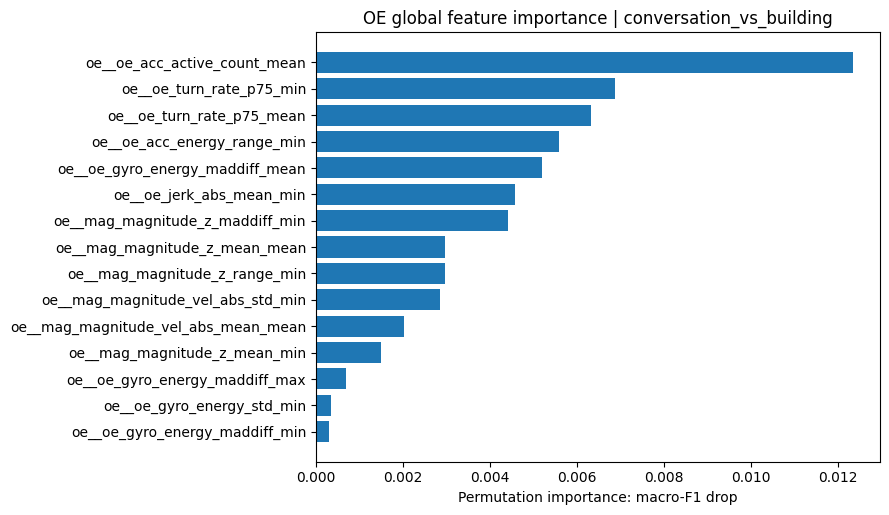

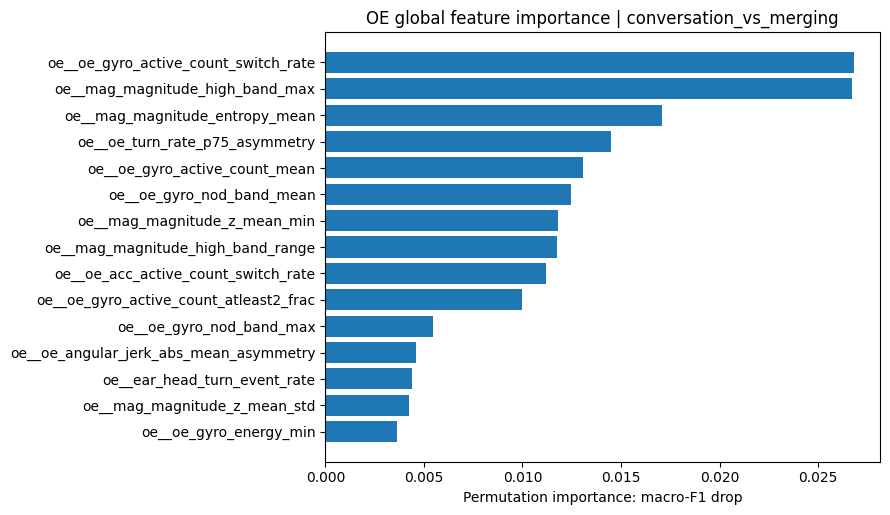

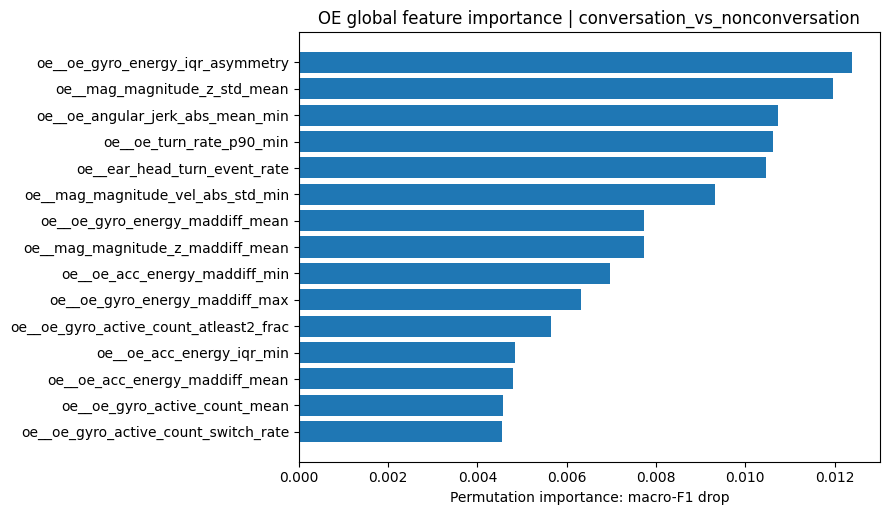

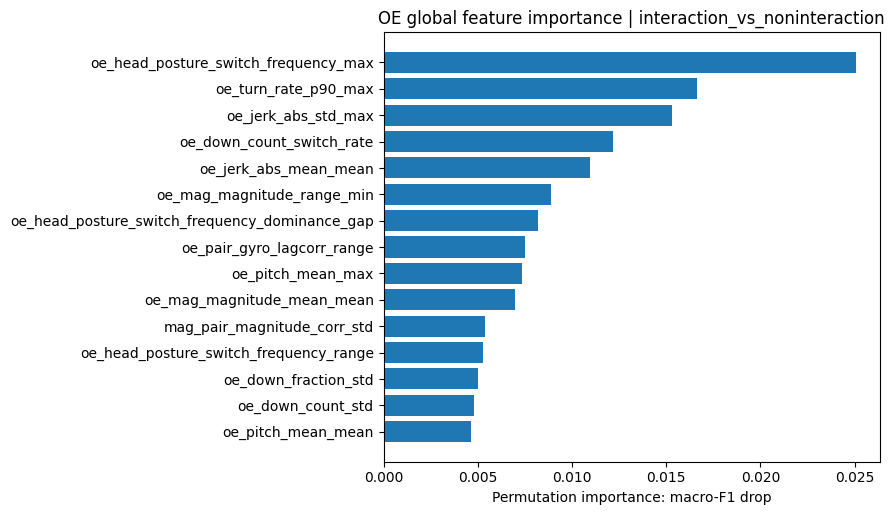

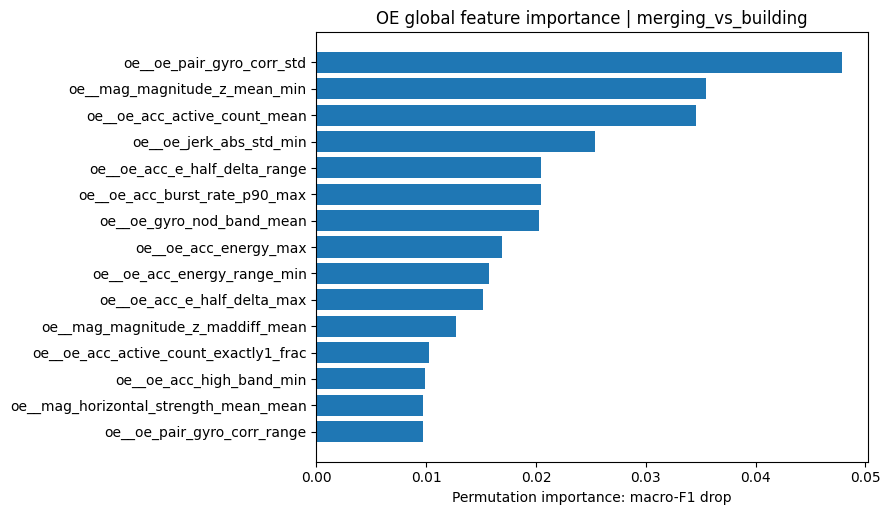

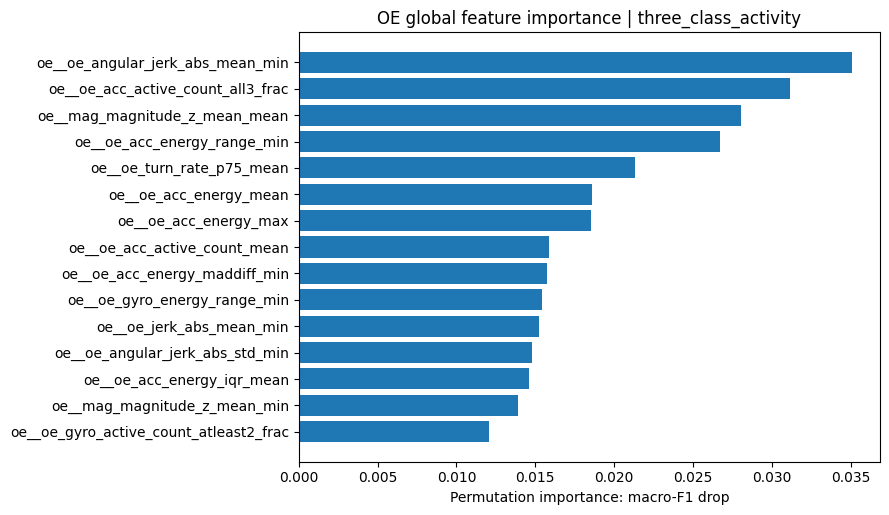


Creating OE class-wise feature force plots...


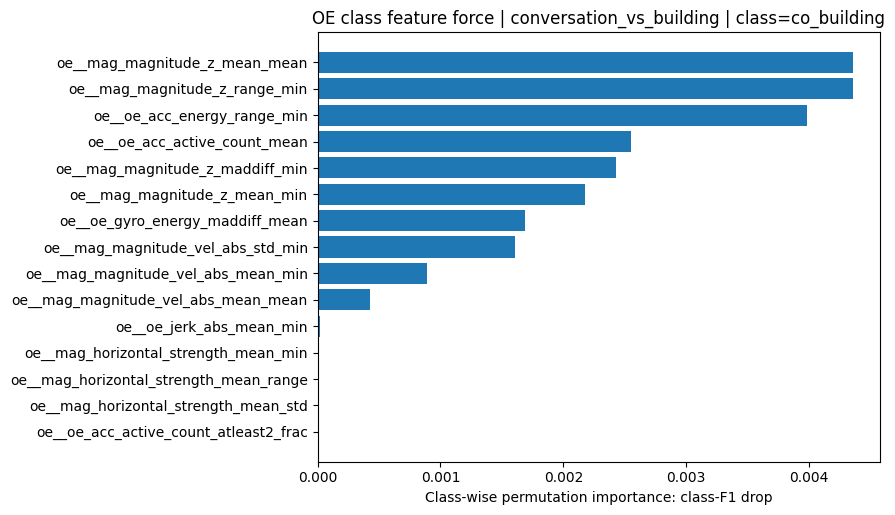

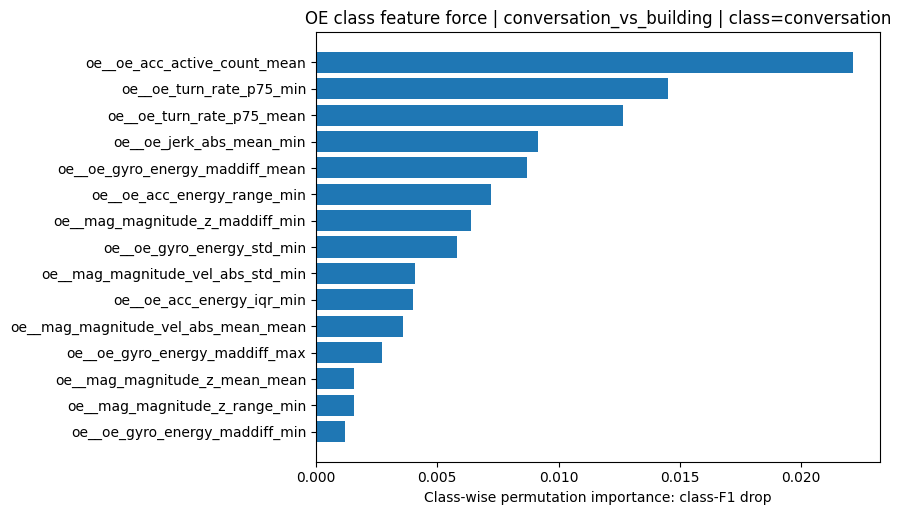

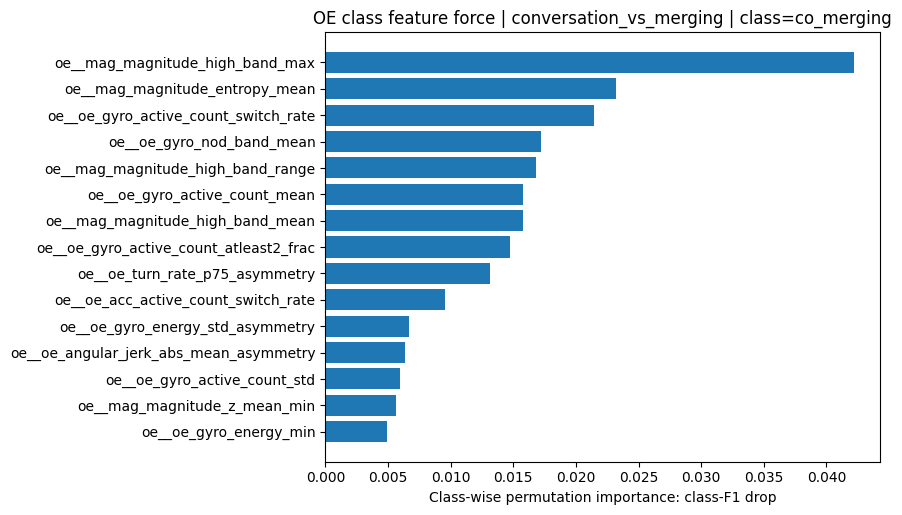

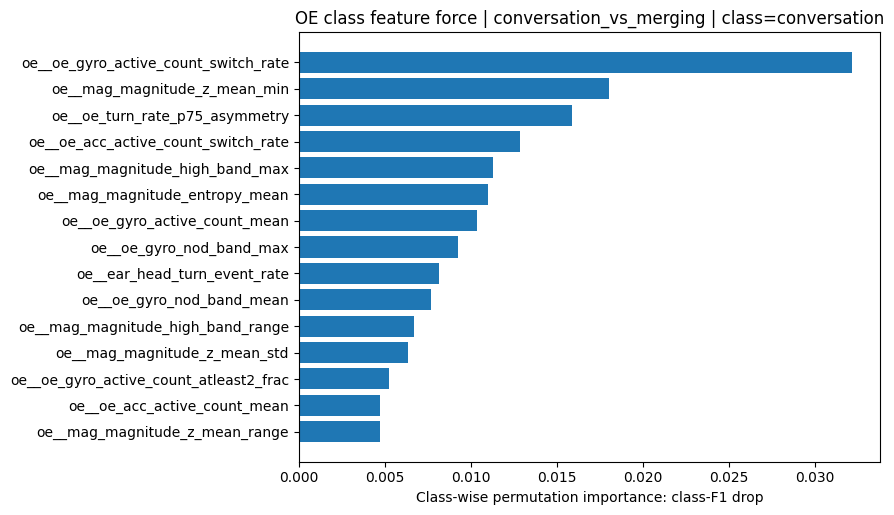

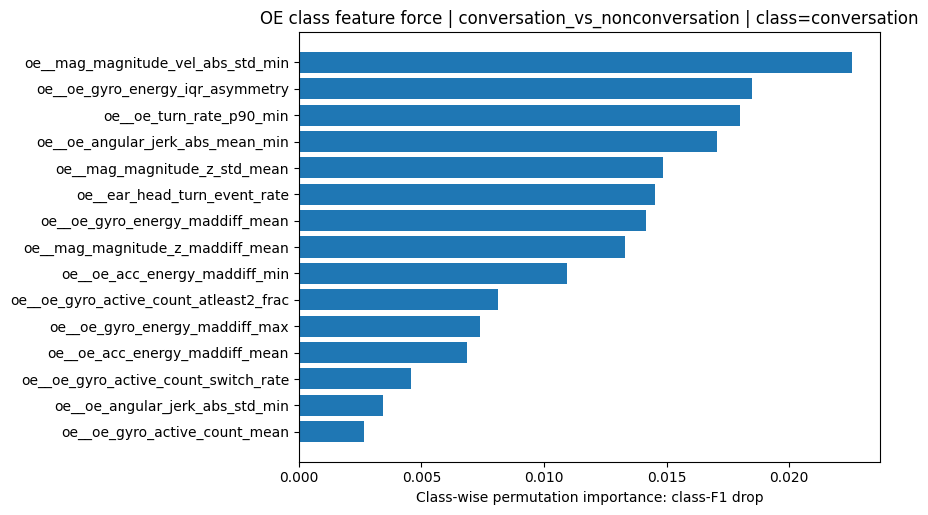

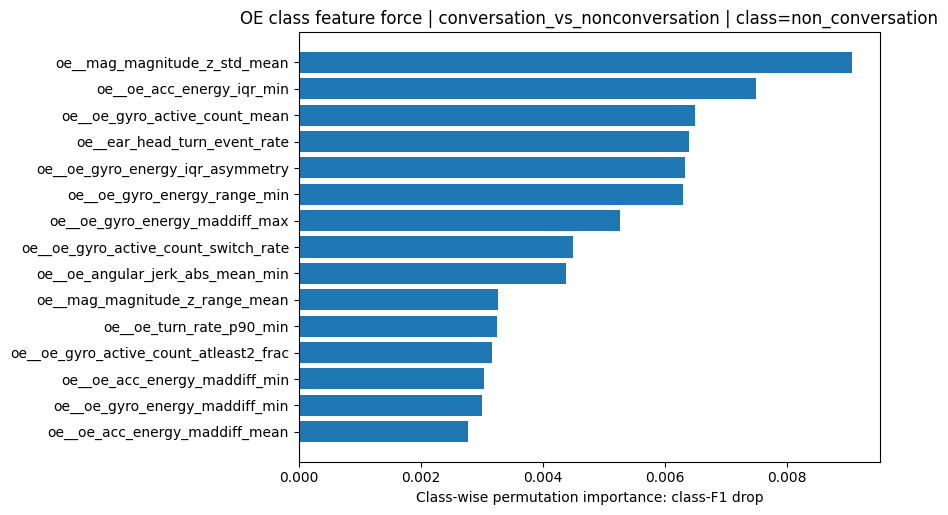

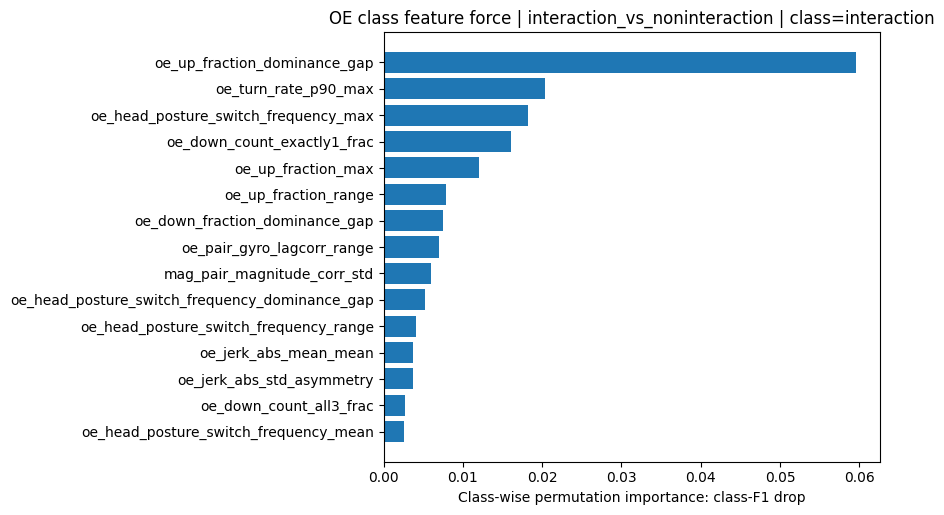

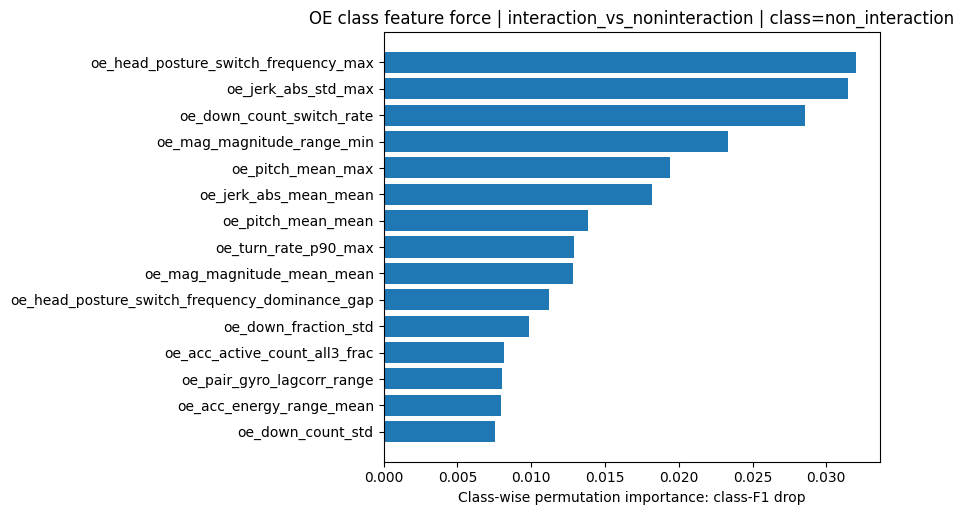

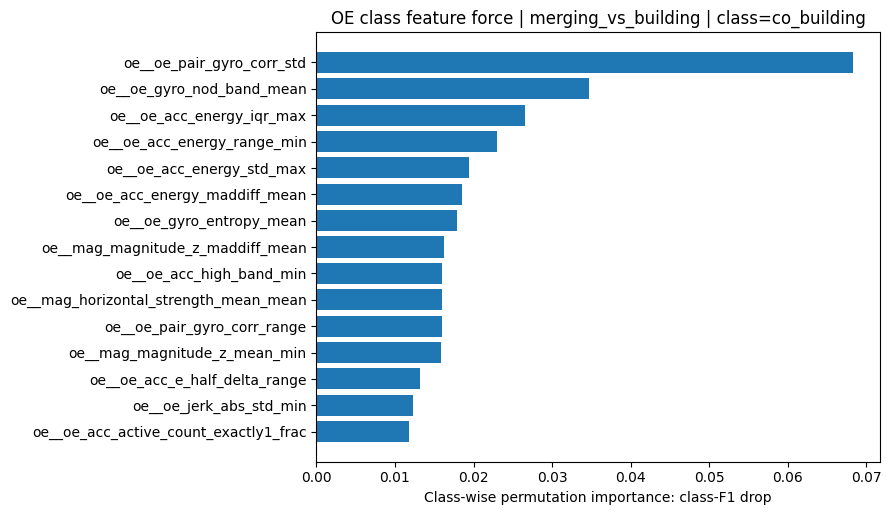

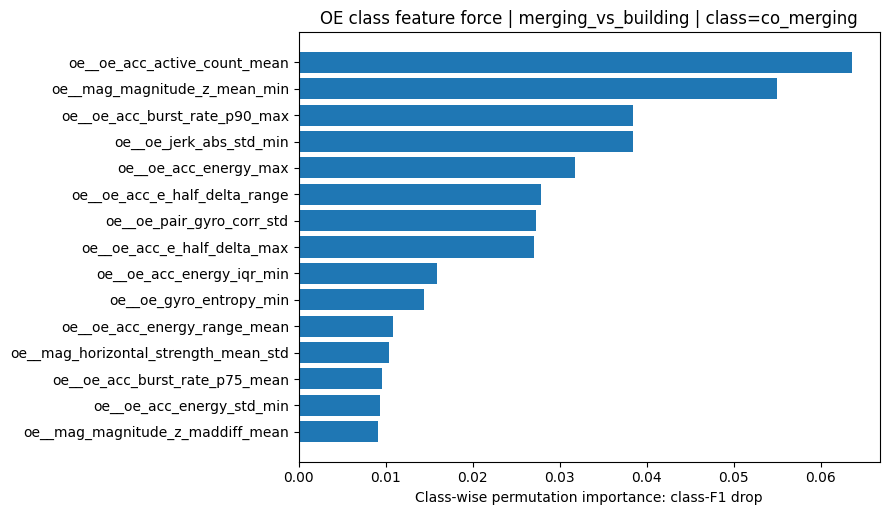

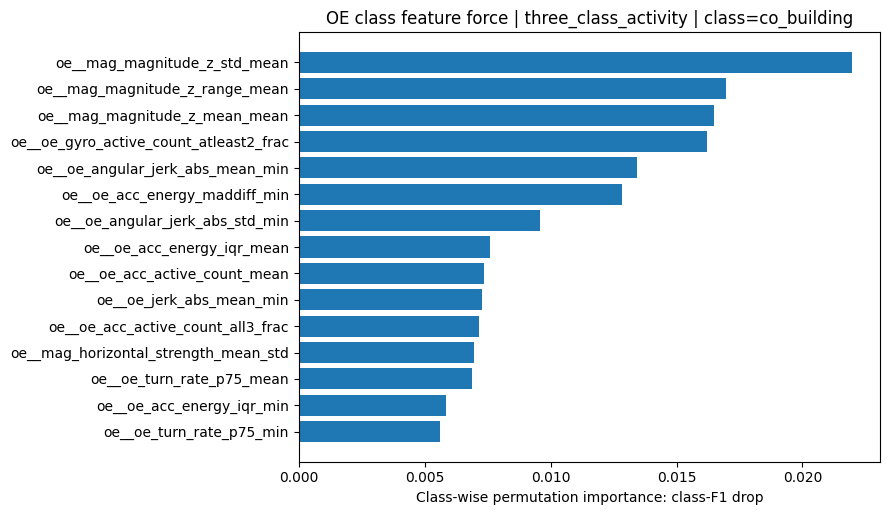

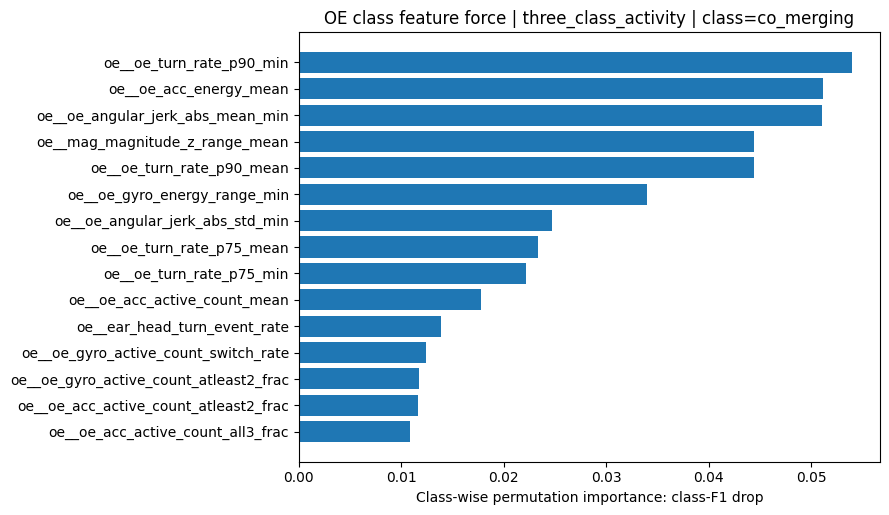

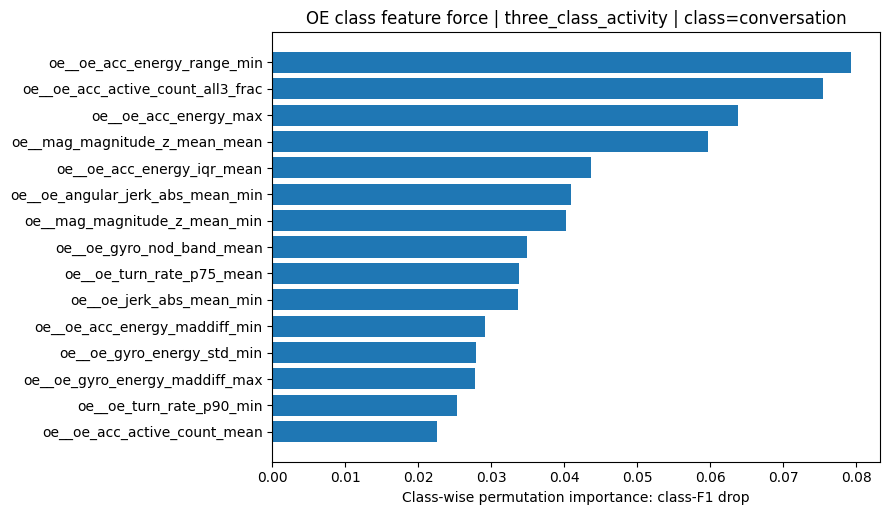


DONE.
OE-only explainability outputs saved in:
/content/drive/MyDrive/thesis/data/ALL_SENSOR_MULTI_TASK_ABLATIONS/FAST_DL_EXPLAINABILITY/OE_ONLY_SUMMARY

Key output files:
- oe_best_models_per_task.csv
- oe_top_global_features_by_task.csv
- oe_class_force_top_features_by_task_class.csv
- oe_compact_interpretation_table.csv
- plots/


In [ ]:
# ================================================================
# OE-ONLY EXPLAINABILITY SUMMARY CELL
# Reads already-created explainability outputs and focuses only on OE.
# It shows:
#   1) best OE fast DL model per task
#   2) OE global feature importance
#   3) OE class-wise feature force
#   4) plots for OE explainability
# ================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------
# PATHS
# ------------------------------------------------

EXPLAIN_OUT_DIR = os.path.join(
    OUT_DIR,
    "FAST_DL_EXPLAINABILITY"
)

OE_EXPLAIN_OUT_DIR = os.path.join(
    EXPLAIN_OUT_DIR,
    "OE_ONLY_SUMMARY"
)

os.makedirs(OE_EXPLAIN_OUT_DIR, exist_ok=True)

print("Reading explainability outputs from:")
print(EXPLAIN_OUT_DIR)

print("\nSaving OE-only summaries to:")
print(OE_EXPLAIN_OUT_DIR)


# ------------------------------------------------
# LOAD FILES
# ------------------------------------------------

plan_path = os.path.join(EXPLAIN_OUT_DIR, "explainability_plan.csv")
base_path = os.path.join(EXPLAIN_OUT_DIR, "fast_dl_explainability_base_overall.csv")
global_path = os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_global_summary.csv")
class_path = os.path.join(EXPLAIN_OUT_DIR, "fast_dl_permutation_importance_classwise_summary.csv")

required_paths = {
    "explainability_plan": plan_path,
    "base_overall": base_path,
    "global_importance": global_path,
    "classwise_importance": class_path,
}

missing = [name for name, path in required_paths.items() if not os.path.exists(path)]

if missing:
    print("Missing files:", missing)
    print("\nYou probably need to run the main explainability cell first.")
    print("At minimum, it should create:")
    for name, path in required_paths.items():
        print("-", path)
    raise FileNotFoundError("Some explainability output files are missing.")

plan_df = pd.read_csv(plan_path)
base_df = pd.read_csv(base_path)
global_df = pd.read_csv(global_path)
class_df = pd.read_csv(class_path)

print("\nLoaded files:")
print("Plan rows:", len(plan_df))
print("Base performance rows:", len(base_df))
print("Global importance rows:", len(global_df))
print("Class-wise importance rows:", len(class_df))


# ------------------------------------------------
# FILTER OE-ONLY
# ------------------------------------------------

oe_plan = plan_df[plan_df["sensor_combo"] == "OE"].copy()
oe_base = base_df[base_df["sensor_combo"] == "OE"].copy()
oe_global = global_df[global_df["sensor_combo"] == "OE"].copy()
oe_class = class_df[class_df["sensor_combo"] == "OE"].copy()

if len(oe_plan) == 0:
    raise ValueError("No OE rows found in explainability_plan.csv.")

if len(oe_global) == 0:
    raise ValueError(
        "No OE global importance rows found. "
        "The main explainability cell may not have completed OE rows."
    )

if len(oe_class) == 0:
    raise ValueError(
        "No OE class-wise importance rows found. "
        "The main explainability cell may not have completed OE rows."
    )


# ------------------------------------------------
# OE BEST MODEL PER TASK
# ------------------------------------------------

oe_plan_best = (
    oe_plan
    .sort_values(["task", "macro_f1", "accuracy"], ascending=[True, False, False])
    .groupby("task", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

# If base rerun metrics are available, merge them.
oe_base_short = oe_base[
    [
        "task", "sensor_combo", "model_type", "seed", "seq_len", "k_features",
        "accuracy", "macro_f1", "balanced_accuracy", "n_sequences",
        "is_overall_best_for_task"
    ]
].copy()

oe_base_short = oe_base_short.rename(columns={
    "accuracy": "explainability_rerun_accuracy",
    "macro_f1": "explainability_rerun_macro_f1",
    "balanced_accuracy": "explainability_rerun_balanced_accuracy",
    "n_sequences": "explainability_n_sequences",
})

oe_best = oe_plan_best.merge(
    oe_base_short,
    on=["task", "sensor_combo", "model_type", "seed", "seq_len", "k_features"],
    how="left"
)

oe_best = oe_best[
    [
        "task",
        "sensor_combo",
        "model_type",
        "seq_len",
        "k_features",
        "accuracy",
        "macro_f1",
        "explainability_rerun_accuracy",
        "explainability_rerun_macro_f1",
        "explainability_rerun_balanced_accuracy",
        "is_overall_best_for_task_x",
    ]
].rename(columns={
    "accuracy": "fast_dl_summary_accuracy",
    "macro_f1": "fast_dl_summary_macro_f1",
    "is_overall_best_for_task_x": "is_overall_best_among_all_sensors",
})

oe_best.to_csv(
    os.path.join(OE_EXPLAIN_OUT_DIR, "oe_best_models_per_task.csv"),
    index=False
)

print("\n" + "=" * 100)
print("OE-ONLY BEST FAST DL MODELS PER TASK")
print("=" * 100)

display(oe_best.round(4))


# ------------------------------------------------
# OE GLOBAL FEATURE IMPORTANCE
# ------------------------------------------------

OE_TOP_N = 15

oe_global_top = (
    oe_global
    .sort_values(
        ["task", "mean_macro_f1_drop", "mean_accuracy_drop"],
        ascending=[True, False, False]
    )
    .groupby(["task", "sensor_combo", "model_type"], as_index=False)
    .head(OE_TOP_N)
    .reset_index(drop=True)
)

oe_global_top.to_csv(
    os.path.join(OE_EXPLAIN_OUT_DIR, "oe_top_global_features_by_task.csv"),
    index=False
)

print("\n" + "=" * 100)
print("OE GLOBAL FEATURE IMPORTANCE")
print("Higher mean_macro_f1_drop means the feature was more important.")
print("=" * 100)

display(
    oe_global_top[
        [
            "task",
            "model_type",
            "feature",
            "mean_macro_f1_drop",
            "mean_accuracy_drop",
            "mean_selector_f_score",
            "n_folds",
        ]
    ].round(5)
)


# ------------------------------------------------
# OE CLASS-WISE FEATURE FORCE
# ------------------------------------------------

oe_class_top = (
    oe_class
    .sort_values(
        ["task", "class_label", "mean_class_f1_drop"],
        ascending=[True, True, False]
    )
    .groupby(["task", "sensor_combo", "model_type", "class_label"], as_index=False)
    .head(OE_TOP_N)
    .reset_index(drop=True)
)

oe_class_top.to_csv(
    os.path.join(OE_EXPLAIN_OUT_DIR, "oe_class_force_top_features_by_task_class.csv"),
    index=False
)

print("\n" + "=" * 100)
print("OE CLASS-WISE FEATURE FORCE")
print("Higher mean_class_f1_drop means the feature was more important for that class.")
print("=" * 100)

display(
    oe_class_top[
        [
            "task",
            "model_type",
            "class_label",
            "feature",
            "mean_class_f1_drop",
            "mean_base_class_f1",
            "mean_selector_f_score",
            "n_folds",
        ]
    ].round(5)
)


# ------------------------------------------------
# COMPACT OE INTERPRETATION TABLE
# ------------------------------------------------

oe_interpretation = []

for task_name, sub in oe_global_top.groupby("task"):
    best_model = oe_best[oe_best["task"] == task_name]

    if len(best_model) > 0:
        model_type = best_model.iloc[0]["model_type"]
        macro_f1 = best_model.iloc[0]["fast_dl_summary_macro_f1"]
        acc = best_model.iloc[0]["fast_dl_summary_accuracy"]
    else:
        model_type = "unknown"
        macro_f1 = None
        acc = None

    top_features = (
        sub
        .sort_values("mean_macro_f1_drop", ascending=False)
        .head(5)["feature"]
        .tolist()
    )

    oe_interpretation.append({
        "task": task_name,
        "best_oe_model": model_type,
        "oe_accuracy": acc,
        "oe_macro_f1": macro_f1,
        "top_5_oe_explanatory_features": "; ".join(top_features),
    })

oe_interpretation = pd.DataFrame(oe_interpretation)

oe_interpretation.to_csv(
    os.path.join(OE_EXPLAIN_OUT_DIR, "oe_compact_interpretation_table.csv"),
    index=False
)

print("\n" + "=" * 100)
print("COMPACT OE INTERPRETATION TABLE")
print("=" * 100)

display(oe_interpretation.round(4))


# ------------------------------------------------
# PLOTS: OE GLOBAL IMPORTANCE PER TASK
# ------------------------------------------------

plot_dir = os.path.join(OE_EXPLAIN_OUT_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

def safe_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(":", "_")

print("\nCreating OE global importance plots...")

for task_name, sub in oe_global_top.groupby("task"):
    sub = sub.sort_values("mean_macro_f1_drop", ascending=False).head(OE_TOP_N)

    plt.figure(figsize=(9, max(4, 0.35 * len(sub))))
    plt.barh(sub["feature"][::-1], sub["mean_macro_f1_drop"][::-1])
    plt.xlabel("Permutation importance: macro-F1 drop")
    plt.title(f"OE global feature importance | {task_name}")
    plt.tight_layout()

    out_path = os.path.join(
        plot_dir,
        f"oe_global_importance_{safe_name(task_name)}.png"
    )

    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


# ------------------------------------------------
# PLOTS: OE CLASS FORCE PER TASK AND CLASS
# ------------------------------------------------

print("\nCreating OE class-wise feature force plots...")

for (task_name, class_label), sub in oe_class_top.groupby(["task", "class_label"]):
    sub = sub.sort_values("mean_class_f1_drop", ascending=False).head(OE_TOP_N)

    plt.figure(figsize=(9, max(4, 0.35 * len(sub))))
    plt.barh(sub["feature"][::-1], sub["mean_class_f1_drop"][::-1])
    plt.xlabel("Class-wise permutation importance: class-F1 drop")
    plt.title(f"OE class feature force | {task_name} | class={class_label}")
    plt.tight_layout()

    out_path = os.path.join(
        plot_dir,
        f"oe_class_force_{safe_name(task_name)}_{safe_name(class_label)}.png"
    )

    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


print("\nDONE.")
print("OE-only explainability outputs saved in:")
print(OE_EXPLAIN_OUT_DIR)

print("\nKey output files:")
print("- oe_best_models_per_task.csv")
print("- oe_top_global_features_by_task.csv")
print("- oe_class_force_top_features_by_task_class.csv")
print("- oe_compact_interpretation_table.csv")
print("- plots/")